In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# EDA

# Step-1 Read the data

In [229]:
data = pd.read_csv('train_data.csv')
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


# Step-2 Preprocess the data

In [232]:
cat = data.select_dtypes(include='object').columns
num = data.select_dtypes(exclude='object').columns

In [234]:
cat

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [236]:
num

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [238]:
data.shape

(614, 13)

In [239]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [241]:
data.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [243]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [244]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [245]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [247]:
data.isnull().sum().sum()

149

# Step-3 Data Cleaning

In [249]:
data.duplicated().sum()

0

In [251]:
data['Dependents'] = data['Dependents'].str.replace('+','',regex=False)

In [253]:
data.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


# Step-4 Missing Value Analysis

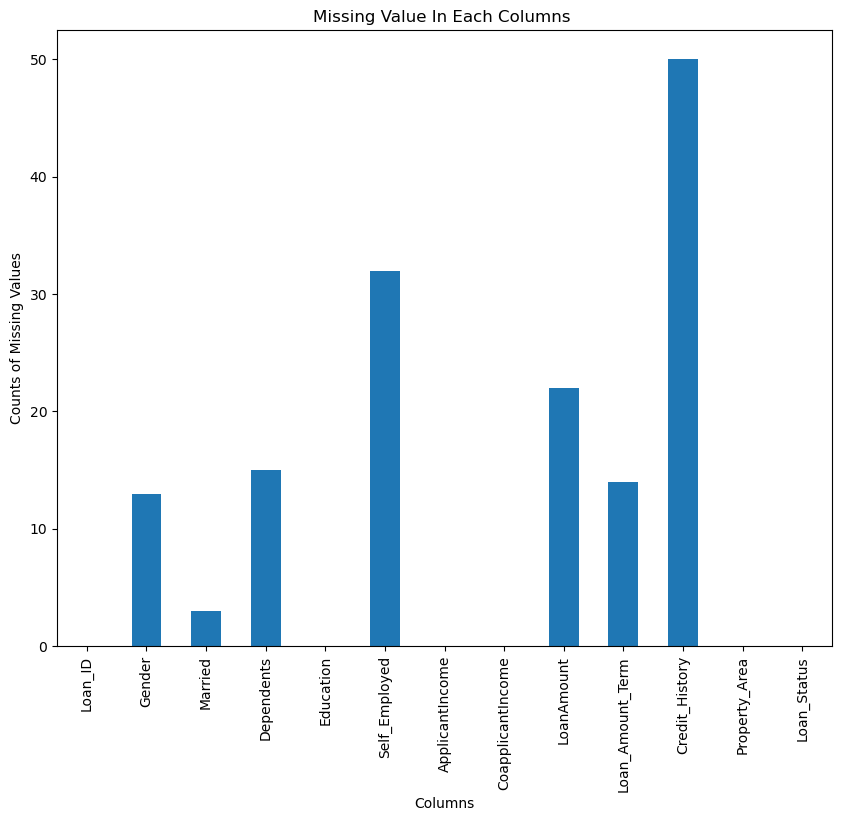

In [256]:
# useful to see how many missing values in every columns
data.isnull().sum().plot(kind='bar',figsize=(10,8))
plt.title('Missing Value In Each Columns ')
plt.xlabel('Columns')
plt.ylabel('Counts of Missing Values')
plt.show()

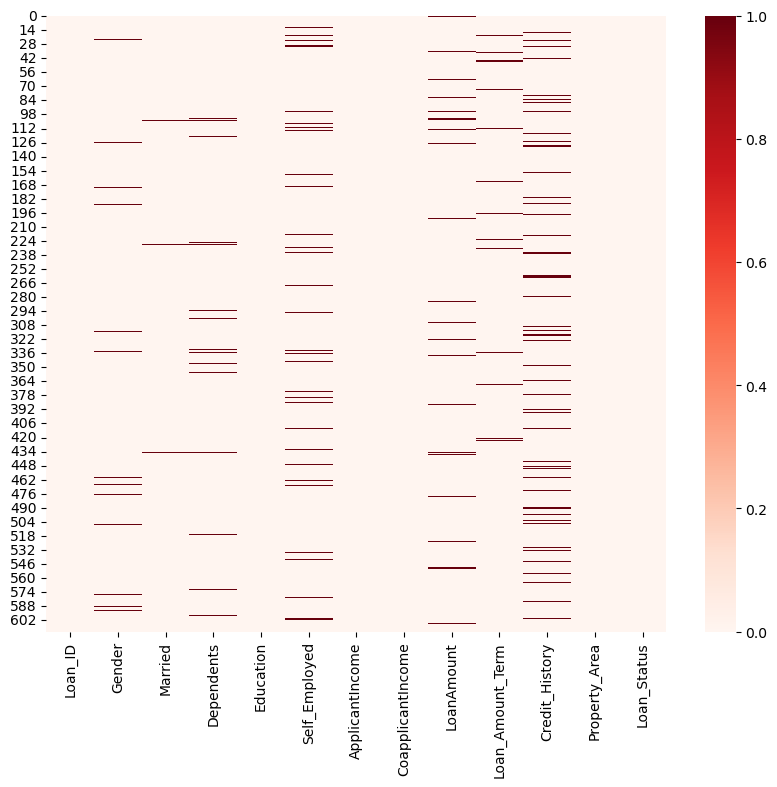

In [258]:
# Useful to see where missing values are in the data (row-wise).
plt.figure(figsize=(10,8))
sns.heatmap(data.isnull(),cmap="Reds")
plt.show()

In [259]:
# Number of missing value columns 
# 3 categorical columns - Gender, Married, Self Employee
# 4 numerical columns - Dependents, loan amount, loan amount tenure, credit history 

**Categorical columns** - filing with mode

**Numerical columns**   - filling with mode,median

For numerical columns → use:

- Column	            Best method 	 Why?

- Dependents         	mode	        It looks like category (0,1,2,3+)
- LoanAmount	        median	        Safe from outliers
- Loan_Amount_Term	    mode	        Mostly fixed values (like 360, 180)
- Credit_History	    mode	        Only 0 or 1 (binary), so use mode

In [263]:
# one of the good method but little lengthy

# fill_values = {
#               'Gender':data['Gender'].mode()[0],  # [0] → picks the first most common value because result in series 
#               'Married': data['Married'].mode()[0],
#               'Self_Employed': data['Married'].mode()[0],
#               'Dependents':data['Dependents'].mode()[0],
#               'LoanAmount':data['LoanAmount'].median(),
#               'Loan_Amount_Term':data['Loan_Amount_Term'].mode()[0],
#               'Credit_History':data['Credit_History'].mode()[0]
# }

# data.fillna(fill_values,inplace=True)

In [264]:
import warnings
warnings.filterwarnings('ignore')

In [266]:
cat_cols = ['Gender', 'Married', 'Self_Employed', 'Dependents', 'Loan_Amount_Term', 'Credit_History']
for col in cat_cols:
    data[col].fillna(data[col].mode()[0],inplace=True)

data['LoanAmount'].fillna(data['LoanAmount'].median(),inplace=True)

In [267]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [268]:
data['Dependents'] = data['Dependents'].astype(int) 
# change the data type
# because of missing value we ot able to this above 

In [270]:
data.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents             int32
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [271]:
cat1 = data.select_dtypes(include='object').columns
num1 = data.select_dtypes(exclude='object').columns

# Step-5 Categorical Columns Analysis

In [273]:
cat1

Index(['Loan_ID', 'Gender', 'Married', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

**Frequency Table**

In [275]:
for col in range(1,len(cat1)):
    ft = data[cat1[col]].value_counts()
    print(ft)
    print('='*150)

Gender
Male      502
Female    112
Name: count, dtype: int64
Married
Yes    401
No     213
Name: count, dtype: int64
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64
Self_Employed
No     532
Yes     82
Name: count, dtype: int64
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64
Loan_Status
Y    422
N    192
Name: count, dtype: int64


**Bar chart**

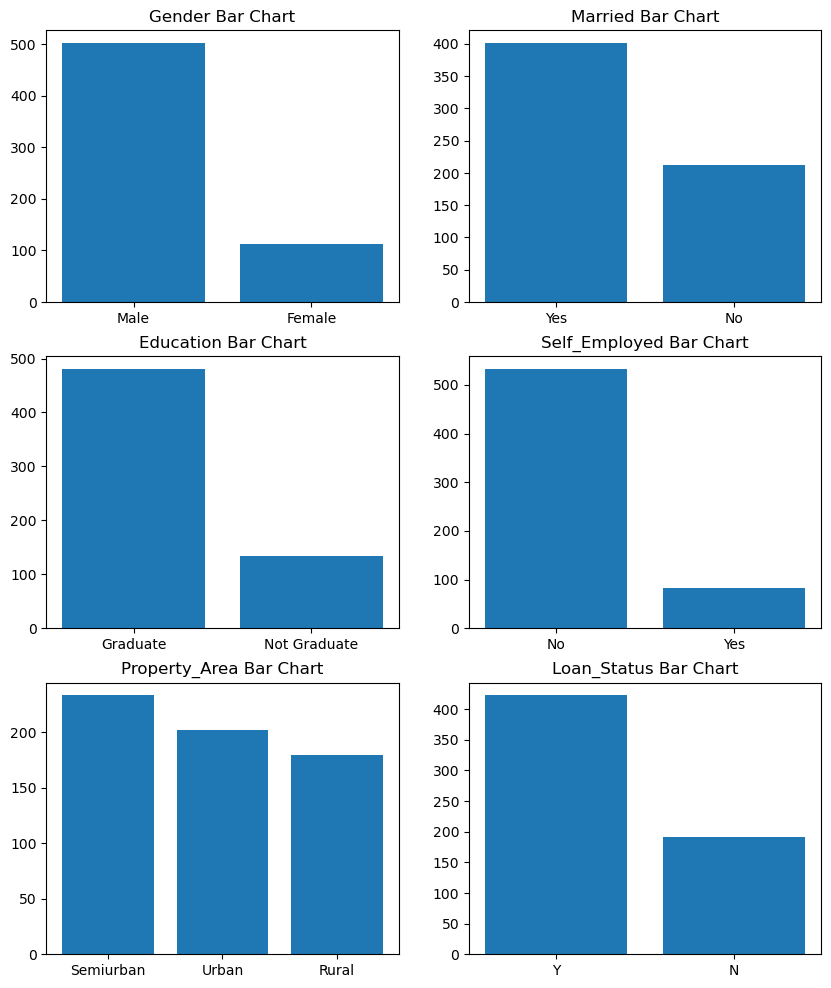

In [279]:
plt.figure(figsize=(10,12))
for col in range(1,len(cat1)):
    keys= data[cat1[col]].value_counts().keys()
    values= data[cat1[col]].value_counts().values
    plt.subplot(3,2,col)
    plt.bar(keys,values)
    plt.title(f'{cat1[col]} Bar Chart')

**Relative Frequency Table**

In [281]:
for col in range(1,len(cat1)):
    RFT = data[cat1[col]].value_counts(normalize=True)*100
    print(RFT)
    print('='*150)

Gender
Male      81.758958
Female    18.241042
Name: proportion, dtype: float64
Married
Yes    65.309446
No     34.690554
Name: proportion, dtype: float64
Education
Graduate        78.175896
Not Graduate    21.824104
Name: proportion, dtype: float64
Self_Employed
No     86.644951
Yes    13.355049
Name: proportion, dtype: float64
Property_Area
Semiurban    37.947883
Urban        32.899023
Rural        29.153094
Name: proportion, dtype: float64
Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


**Pie Chart**

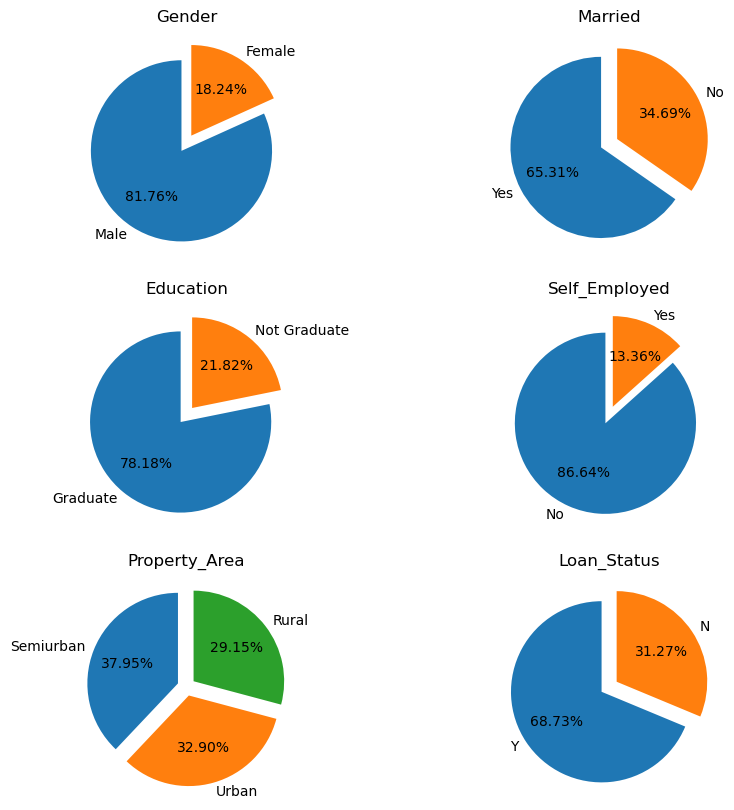

In [283]:
plt.figure(figsize=(10,10))
for cols in range(1,len(cat1)):
    keys = data[cat1[cols]].value_counts().keys()
    values = data[cat1[cols]].value_counts().values
    plt.subplot(3,2,cols)
    plt.pie(x=values,
            explode=[0.1]*len(values),
            labels= keys,
            autopct='%0.2f%%',
            startangle=90)
    plt.title(cat1[cols])
plt.show()

# step-6 Numerical Columns Analysis

In [285]:
num1

Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [286]:
# Statistical Summary
data[num1].describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.744300,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,1.009623,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,1.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,3.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000


**Histogram**

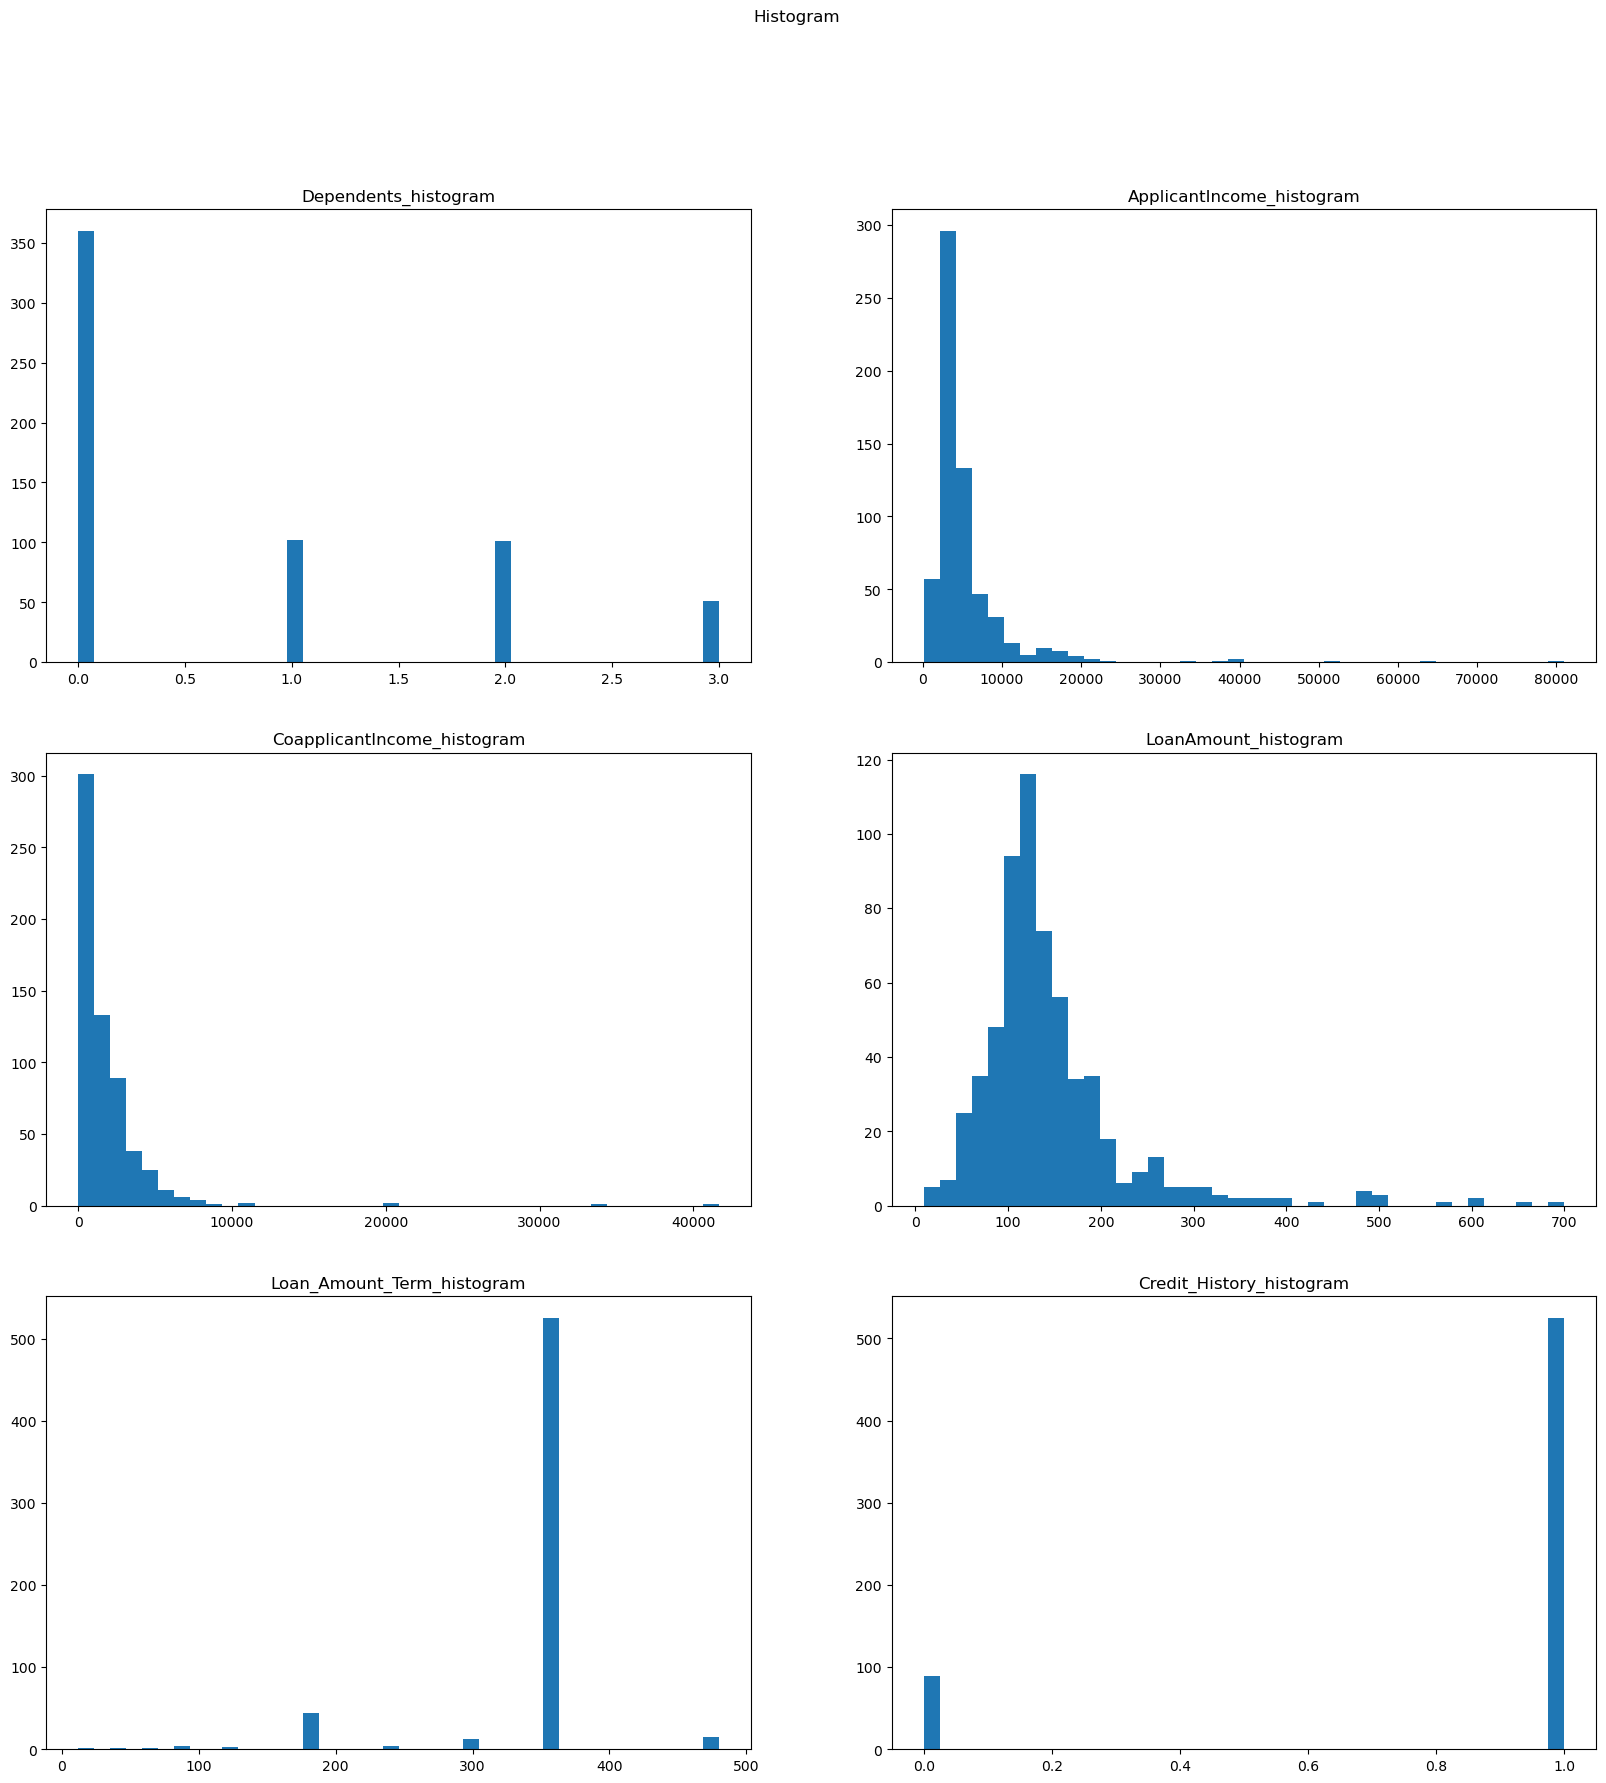

In [288]:
plt.figure(figsize=(20,20))
for col in range(len(num1)):
    plt.subplot(3,2,(col+1))
    plt.hist(data[num1[col]],bins=40)
    plt.title(f'{num1[col]}_histogram')
    plt.suptitle('Histogram')

# Step-7 Outlier Analysis

**Box Plot**

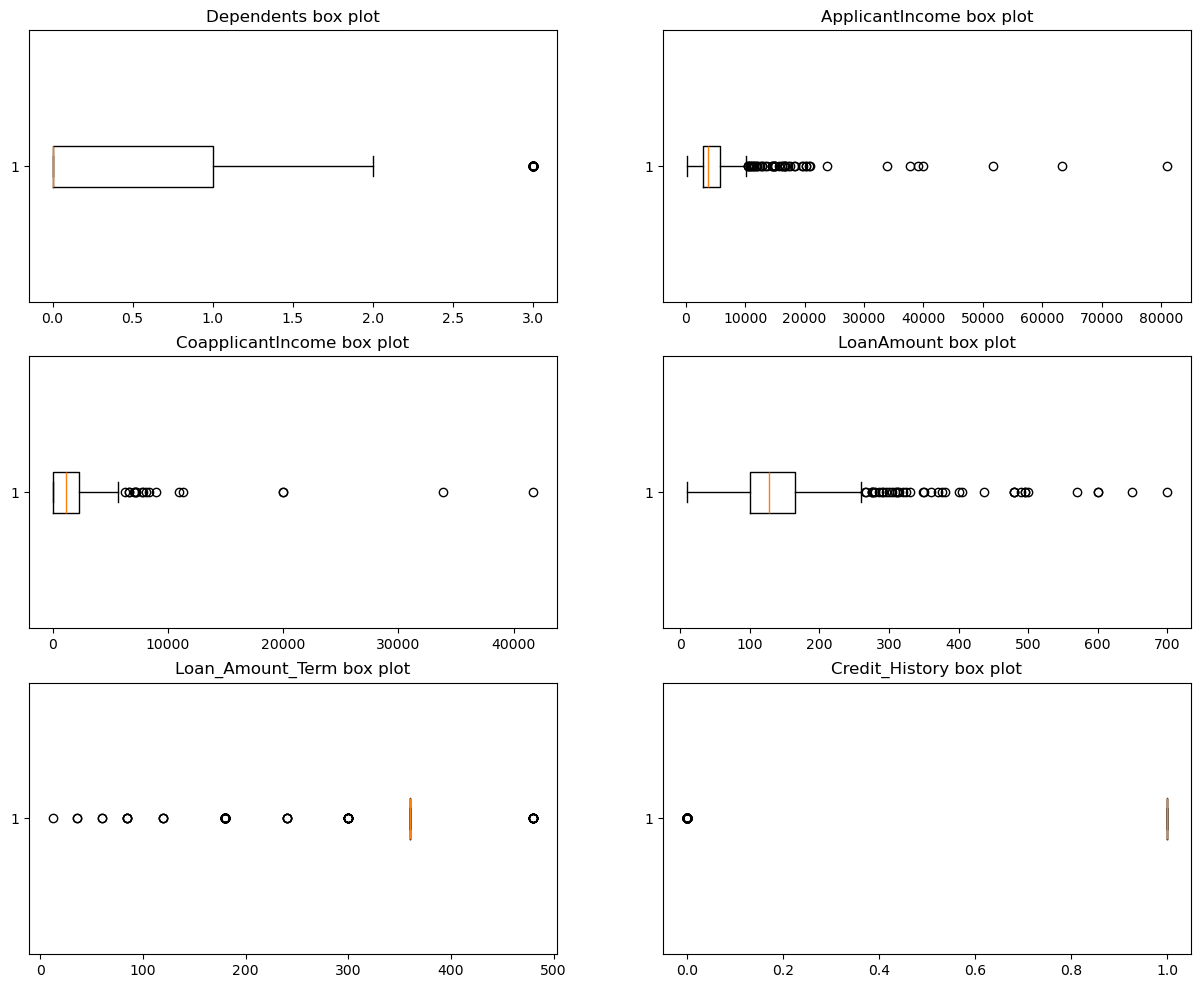

In [293]:
plt.figure(figsize=(15,12))
for cols in range(len(num1)):
    plt.subplot(3,2,(cols+1))
    plt.boxplot(data[num1[cols]],vert=False)
    plt.title(f'{num1[cols]} box plot')
plt.show()

In [294]:
# know the otlier in every column
for col in num1:
    Q1 = round(np.percentile(data[col],25),2)
    Q3 = round(np.percentile(data[col],75),2)
    
    IQR = Q3-Q1
    
    lb = Q1 - IQR*1.5
    ub = Q3 + IQR*1.5
    
    con = (data[col]<lb) | (data[col]>ub)
    
    outlier_df = data[con]
    
    print(f"{col}--{len(outlier_df)} outlier")

outlier_df

Dependents--51 outlier
ApplicantIncome--50 outlier
CoapplicantIncome--18 outlier
LoanAmount--41 outlier
Loan_Amount_Term--88 outlier
Credit_History--89 outlier


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
7,LP001014,Male,Yes,3,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
17,LP001036,Female,No,0,Graduate,No,3510,0.0,76.0,360.0,0.0,Urban,N
20,LP001043,Male,Yes,0,Not Graduate,No,7660,0.0,104.0,360.0,0.0,Urban,N
22,LP001047,Male,Yes,0,Not Graduate,No,2600,1911.0,116.0,360.0,0.0,Semiurban,N
23,LP001050,Male,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
576,LP002872,Male,Yes,0,Graduate,No,3087,2210.0,136.0,360.0,0.0,Semiurban,N
584,LP002911,Male,Yes,1,Graduate,No,2787,1917.0,146.0,360.0,0.0,Rural,N
589,LP002926,Male,Yes,2,Graduate,Yes,2726,0.0,106.0,360.0,0.0,Semiurban,N
597,LP002943,Male,No,0,Graduate,No,2987,0.0,88.0,360.0,0.0,Semiurban,N


**Treat Outlier**

In [297]:
for cols in num1:
    if cols != 'Dependents':
        Q1 = round(np.percentile(data[cols],25),2)
        Q3 = round(np.percentile(data[cols],75),2)
        IQR = Q3 - Q1
        
        lb = Q1 - 1.5*IQR
        ub = Q3 + 1.5*IQR
        
        data[cols] = data[cols].clip(lower=lb, upper=ub)

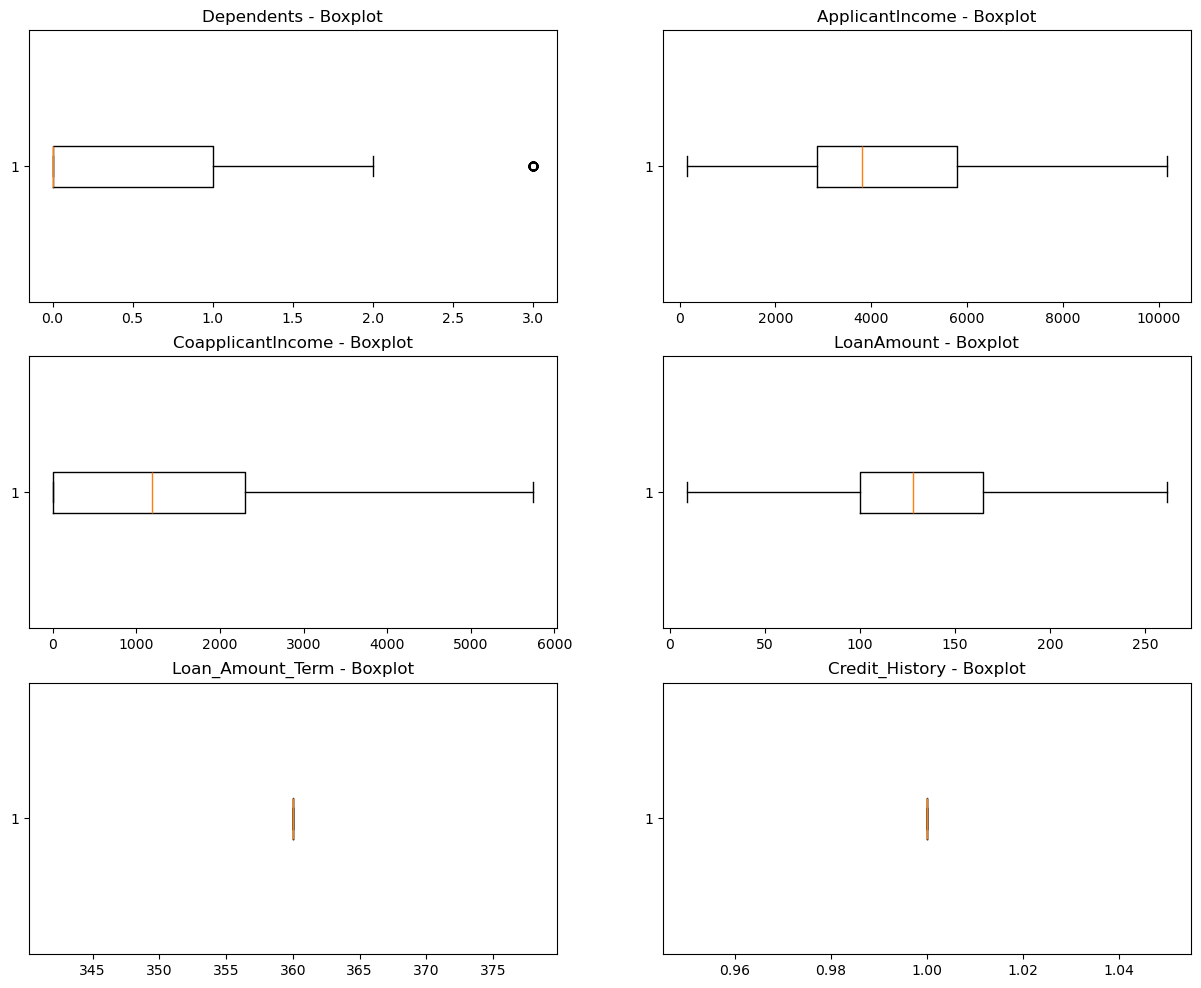

In [299]:
# checking
plt.figure(figsize=(15,12))

for cols in range(len(num1)):
    plt.subplot(3,2,(cols+1))
    plt.boxplot(data[num1[cols]],vert=False)
    plt.title(f'{num1[cols]} - Boxplot')

plt.show()

# Step-8 Bi varient and Multi varient Analysis

In [ ]:
data

**Categorical columns vs Target**

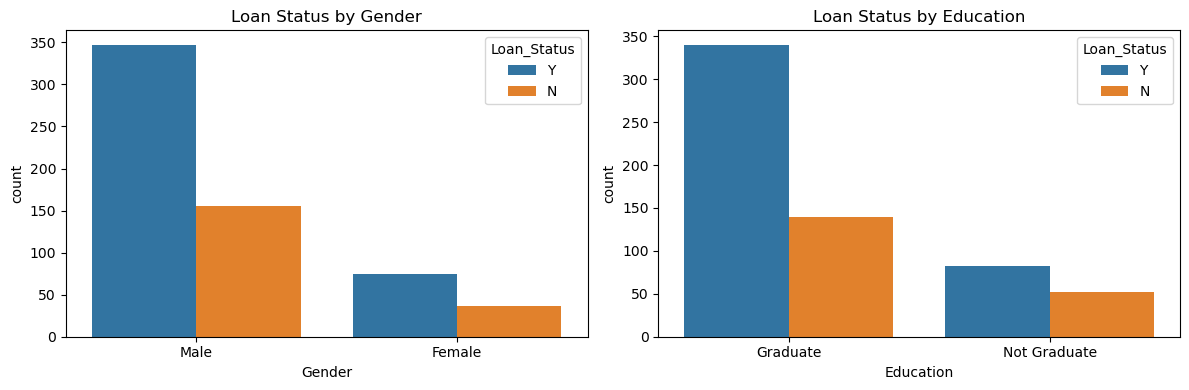

In [327]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='Gender', hue='Loan_Status', data=data, ax=axes[0])
axes[0].set_title('Loan Status by Gender')

sns.countplot(x='Education', hue='Loan_Status', data=data, ax=axes[1])
axes[1].set_title('Loan Status by Education')

plt.tight_layout()
plt.show()


**Numerical columns vs Target**

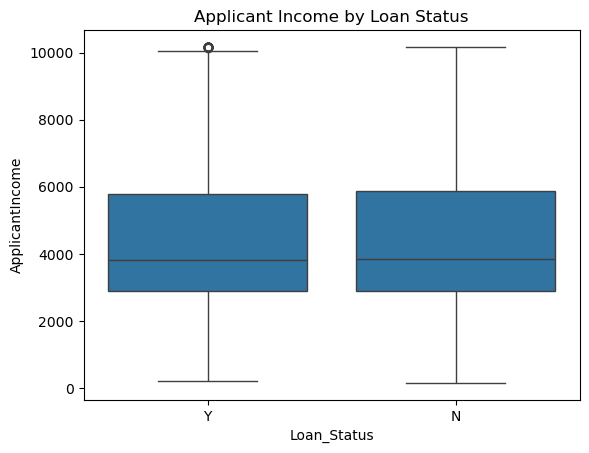

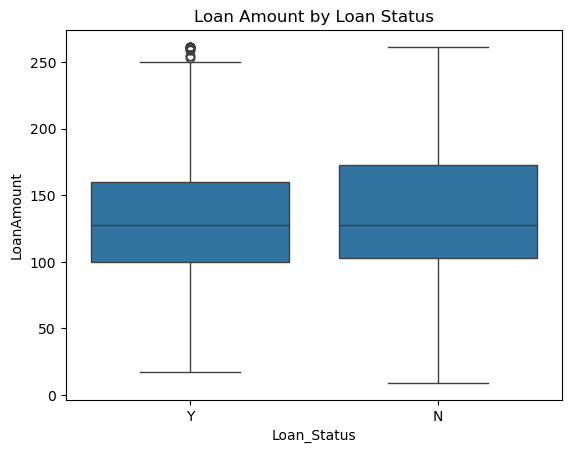

In [343]:
# Boxplot - ApplicantIncome
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=data)
plt.title("Applicant Income by Loan Status")
plt.show()

# Boxplot - LoanAmount
sns.boxplot(x='Loan_Status', y='LoanAmount', data=data)
plt.title("Loan Amount by Loan Status")
plt.show()


In [ ]:
x = data['']

**Numerical vc Numerical**

In [363]:
# Correlation matrix
corr_matrix = data[num1].corr()*100
print(corr_matrix)

                   Dependents  ApplicantIncome  CoapplicantIncome  LoanAmount  \
Dependents         100.000000        11.156451          -3.150955   16.451533   
ApplicantIncome     11.156451       100.000000         -22.895608   55.795250   
CoapplicantIncome   -3.150955       -22.895608         100.000000   26.502136   
LoanAmount          16.451533        55.795250          26.502136  100.000000   
Loan_Amount_Term          NaN              NaN                NaN         NaN   
Credit_History            NaN              NaN                NaN         NaN   

                   Loan_Amount_Term  Credit_History  
Dependents                      NaN             NaN  
ApplicantIncome                 NaN             NaN  
CoapplicantIncome               NaN             NaN  
LoanAmount                      NaN             NaN  
Loan_Amount_Term                NaN             NaN  
Credit_History                  NaN             NaN  


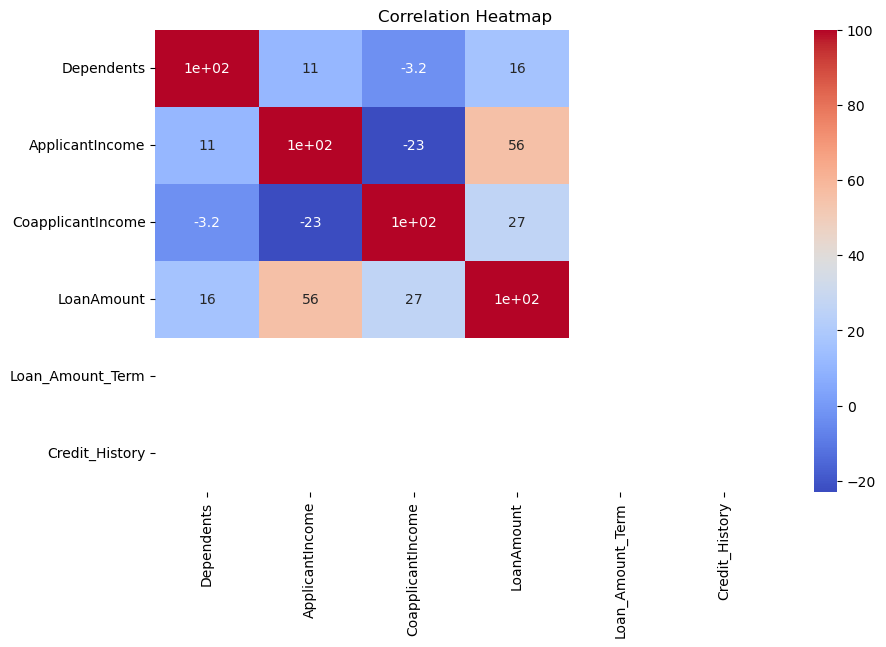

In [365]:
# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


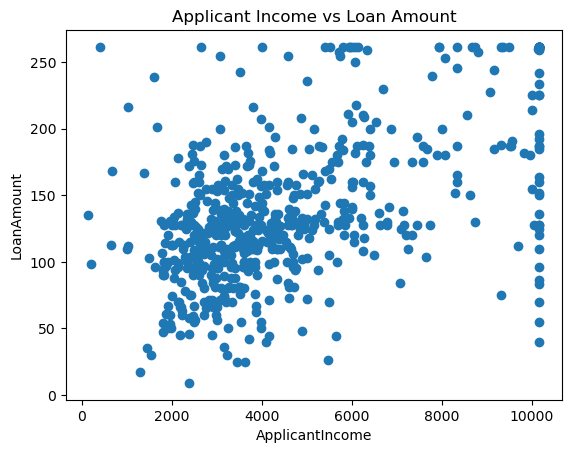

In [368]:
# scateer plot between columns
plt.scatter(data['ApplicantIncome'], data['LoanAmount'])
plt.xlabel('ApplicantIncome')
plt.ylabel('LoanAmount')
plt.title('Applicant Income vs Loan Amount')
plt.show()

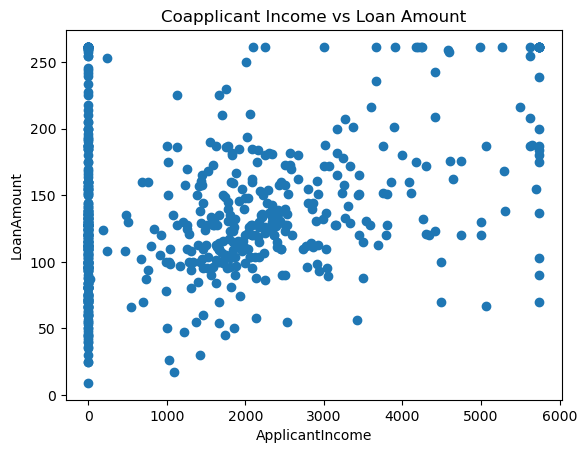

In [374]:
plt.scatter(data['CoapplicantIncome'], data['LoanAmount'])
plt.xlabel('ApplicantIncome')
plt.ylabel('LoanAmount')
plt.title('Coapplicant Income vs Loan Amount')
plt.show()

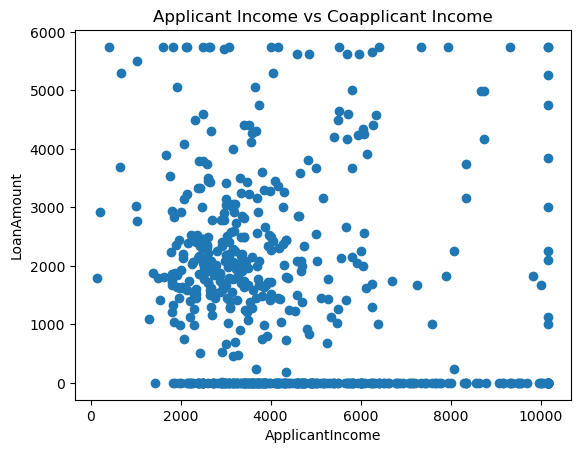

In [376]:
plt.scatter(data['ApplicantIncome'], data['CoapplicantIncome'])
plt.xlabel('ApplicantIncome')
plt.ylabel('LoanAmount')
plt.title('Applicant Income vs Coapplicant Income')
plt.show()

In [ ]:
# by seeing above all three scatter plot
# none of them have a strong relationship with each other

# Feature Engineering

# Step-9 Encoding

In [381]:
cat1

Index(['Loan_ID', 'Gender', 'Married', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [387]:
# how to find which columns go in which encoding 
for col in cat1:
    if data[col].nunique()==2:
        print(f'Label Encoder : {col}')

print('='*100)

for col in cat1:
    if data[col].nunique()>2:
        print(f'Onehot Encoder : {col}')

Label Encoder : Gender
Label Encoder : Married
Label Encoder : Education
Label Encoder : Self_Employed
Label Encoder : Loan_Status
Onehot Encoder : Loan_ID
Onehot Encoder : Property_Area


In [412]:
# Label Encoder
data1 = data.copy()

label_col = ["Gender","Married","Education","Self_Employed","Loan_Status"]
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for cols in label_col:
    data1[cols] = le.fit_transform(data1[cols])

# One-hot encoder
data1 = pd.get_dummies(data1, columns=['Property_Area'], drop_first=True)

In [414]:
data1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,1,False,True
1,LP001003,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,0,False,False
2,LP001005,1,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,1,False,True
3,LP001006,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,1,False,True
4,LP001008,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,1,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,0,0,0,0,2900.0,0.0,71.0,360.0,1.0,1,False,False
610,LP002979,1,1,3,0,0,4106.0,0.0,40.0,360.0,1.0,1,False,False
611,LP002983,1,1,1,0,0,8072.0,240.0,253.0,360.0,1.0,1,False,True
612,LP002984,1,1,2,0,0,7583.0,0.0,187.0,360.0,1.0,1,False,True


In [416]:
dummy_cols = ['Property_Area_Semiurban', 'Property_Area_Urban']
data1[dummy_cols] = data1[dummy_cols].astype(int)

In [418]:
data1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,1,0,1
1,LP001003,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,0,0,0
2,LP001005,1,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,1,0,1
3,LP001006,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,1,0,1
4,LP001008,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,0,0,0,0,2900.0,0.0,71.0,360.0,1.0,1,0,0
610,LP002979,1,1,3,0,0,4106.0,0.0,40.0,360.0,1.0,1,0,0
611,LP002983,1,1,1,0,0,8072.0,240.0,253.0,360.0,1.0,1,0,1
612,LP002984,1,1,2,0,0,7583.0,0.0,187.0,360.0,1.0,1,0,1


# Step-10 Scaling

**standardization**

In [420]:
num1

Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [422]:
data2 = data1.copy()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
for cols in num1: 
    data2[[cols]] = scaler.fit_transform(data2[[cols]])

In [ ]:
# doing scaling column by column in a loop is slower than doing all columns at once like this:
# data1[num1] = scaler.fit_transform(data1[num1])
# Both ways work fine

In [426]:
data2

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,-0.737806,0,0,0.497164,-0.874587,-0.168041,0.0,0.0,1,0,1
1,LP001003,1,1,0.253470,0,0,-0.013767,0.054395,-0.168041,0.0,0.0,0,0,0
2,LP001005,1,1,-0.737806,0,1,-0.652632,-0.874587,-1.280462,0.0,0.0,1,0,1
3,LP001006,1,1,-0.737806,1,0,-0.820924,0.578025,-0.311579,0.0,0.0,1,0,1
4,LP001008,1,0,-0.737806,0,0,0.558104,-0.874587,0.065209,0.0,0.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,0,-0.737806,0,0,-0.692990,-0.874587,-1.190750,0.0,0.0,1,0,0
610,LP002979,1,1,2.236021,0,0,-0.206274,-0.874587,-1.746961,0.0,0.0,1,0,0
611,LP002983,1,1,0.253470,0,0,1.394319,-0.726739,2.074743,0.0,0.0,1,0,1
612,LP002984,1,1,1.244745,0,0,1.196969,-0.874587,0.890553,0.0,0.0,1,0,1


# Feature Selection

# Step-11 PCA

In [430]:
data3 = data2.copy()

In [432]:
x = data3.drop('Loan_Status',axis=1)

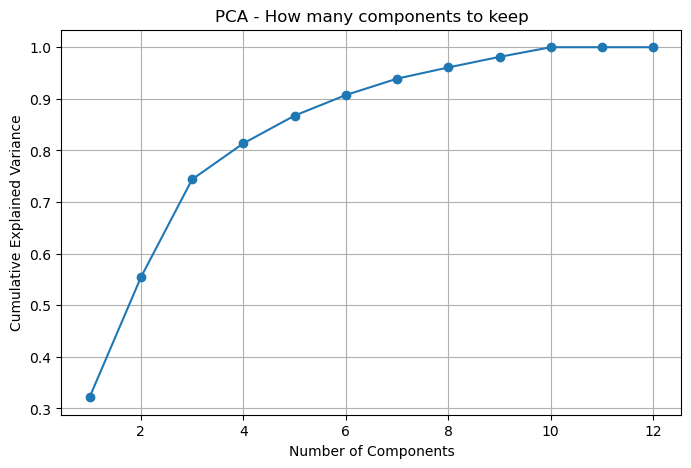

In [438]:
from sklearn.decomposition import PCA

# Step 1: Separate input and output
X = data2.drop(['Loan_ID','Loan_Status'], axis=1)
y = data2['Loan_Status']

# Step 2: Apply PCA
pca = PCA()  # keep all components
X_pca = pca.fit_transform(X)

# Step 3: Check explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - How many components to keep')
plt.grid()
plt.show()


In [ ]:
# by the above plot we can easly find the number of component 
# or if we want then we can take it for our side also 

In [440]:
pca = PCA(n_components=6)
data3 = pca.fit_transform(X)

In [442]:
data3

array([[-0.12928452, -1.05350116, -0.83885207,  0.72693981, -0.1582473 ,
         0.2337348 ],
       [ 0.01173828,  0.07421818,  0.31953912,  0.1066992 ,  0.19672533,
        -0.26374722],
       [-1.48816039, -0.82809736, -0.17269678,  0.75533211,  0.13331976,
        -0.53324732],
       ...,
       [ 2.38676285, -0.59746672, -0.41302879,  0.64475948, -0.86693605,
        -0.37962615],
       [ 1.745316  , -0.97442739,  0.78558775,  0.71960784, -0.23972568,
        -0.1517333 ],
       [-0.3792327 , -0.92550401, -0.81079127, -0.8352304 , -0.26147202,
         0.63596014]])

In [452]:
data3 = pd.DataFrame(data3, columns=[f'PC{i+1}' for i in range(6)])
data3['Loan_Status'] = y

In [454]:
data3

,PC1,PC2,PC3,PC4,PC5,PC6,Loan_Status
0,-0.129285,-1.053501,-0.838852,0.726940,-0.158247,0.233735,1
1,0.011738,0.074218,0.319539,0.106699,0.196725,-0.263747,0
2,-1.488160,-0.828097,-0.172697,0.755332,0.133320,-0.533247,1
3,-0.964089,0.784134,-0.305078,0.743388,-0.229323,-0.544347,1
4,0.069747,-1.017761,-0.898463,0.710464,-0.273460,0.226332,1
...,...,...,...,...,...,...,...
609,-1.632130,-0.927171,-0.413972,-0.077680,-0.178337,0.638625,1
610,-0.638801,-1.120277,2.550286,0.154272,0.811624,0.046688,1
611,2.386763,-0.597467,-0.413029,0.644759,-0.866936,-0.379626,1
612,1.745316,-0.974427,0.785588,0.719608,-0.239726,-0.151733,1


In [456]:
pca.explained_variance_ratio_

array([0.32174283, 0.23203785, 0.19005102, 0.06977585, 0.05378794,
       0.03991405])

In [458]:
pca.explained_variance_

array([1.64944853, 1.18956651, 0.97431658, 0.35771327, 0.27574955,
       0.2046236 ])

In [ ]:
Q) Feature selection after scaling is good or scaling after feature selection is good

- Do scaling first, then feature selection.because

- 1) some feature selection methods use distance or variance, like:
    
    PCA,Lasso,Recursive Feature Elimination (RFE)
    
    These methods need features on the same scale. So scaling is needed before

- 2) If you do feature selection first, unscaled features may mislead the model — features with big values might look more "important."

# Model Development

# Step-12 Train-Test Split

In [471]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.metrics import accuracy_score,\
                            precision_score,\
                            recall_score,\
                            f1_score,\
                            classification_report,\
                            roc_auc_score,roc_curve,auc
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

## Data1

In [489]:
x1 = data1.drop(['Loan_ID','Loan_Status'],axis=1)
y1 = data1['Loan_Status']

In [491]:
X_train, X_test, y_train, y_test = train_test_split(x1,y1, test_size=0.2,random_state=0)


In [493]:
print(X_train.shape),
print(X_test.shape),
print(y_train.shape),
print(y_test.shape)

(491, 12)
(123, 12)
(491,)
(123,)


## KNN

In [496]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()   # Base model
knn

KNeighborsClassifier()

In [499]:
knn_fit = knn.fit(X_train,y_train) 
knn_fit

KNeighborsClassifier()

In [501]:
knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [503]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9],       
    'weights': ['uniform', 'distance'],  
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],  
    'p': [1, 2],  
}


In [505]:
grid_search = GridSearchCV(knn,  # Base model
                           param_grid, # params 
                           scoring='accuracy', # metric
                           cv=5,
                           verbose=True)

grid_search

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [3, 5, 7, 9], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=True)

In [507]:
grid_search.fit(X_train,y_train) 

Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [3, 5, 7, 9], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=True)

In [509]:
grid_search.best_estimator_ 

KNeighborsClassifier(n_neighbors=9)

In [511]:
grid_search.best_score_

0.6477221191506906

In [513]:
grid_search.best_params_

{'algorithm': 'auto', 'n_neighbors': 9, 'p': 2, 'weights': 'uniform'}

**BY Base Model**

accuray is: 62.6
F1 is: 0.76
Precision is: 0.72
Recall is: 0.79
              precision    recall  f1-score   support

           0       0.24      0.18      0.21        33
           1       0.72      0.79      0.76        90

    accuracy                           0.63       123
   macro avg       0.48      0.49      0.48       123
weighted avg       0.59      0.63      0.61       123



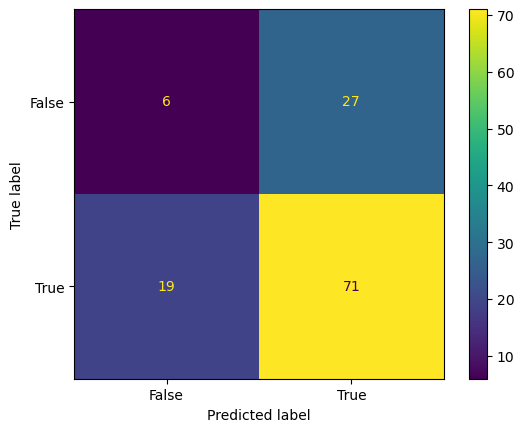

True negative: 6
False postive: 27
False negative: 19
True postive: 71


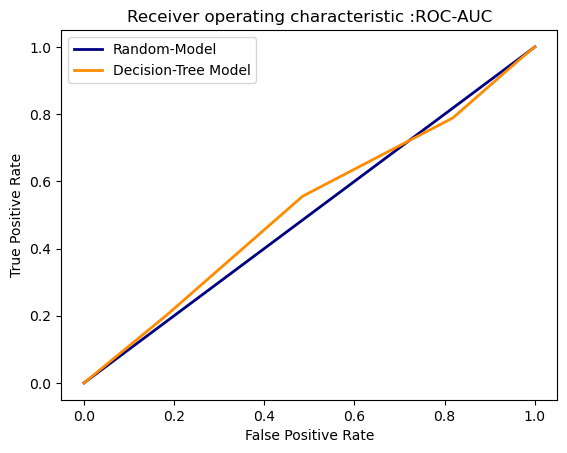

Computed Area Under the Curve (AUC) 0.5195286195286196


In [516]:
# ============================= Predictions ============================================================

y_pred_dt=knn_fit.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=knn_fit.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Decision-Tree Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [518]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
knn_base = pd.DataFrame(data,
                  index = idx,
                  columns=['Base Model'])
knn_base

,Base Model
Accuracy,62.60
f1,0.76
Precision,0.72
Recall,0.79


**BY Hyper Tuned**

accuray is: 67.48
F1 is: 0.8
Precision is: 0.73
Recall is: 0.89
              precision    recall  f1-score   support

           0       0.23      0.09      0.13        33
           1       0.73      0.89      0.80        90

    accuracy                           0.67       123
   macro avg       0.48      0.49      0.47       123
weighted avg       0.59      0.67      0.62       123



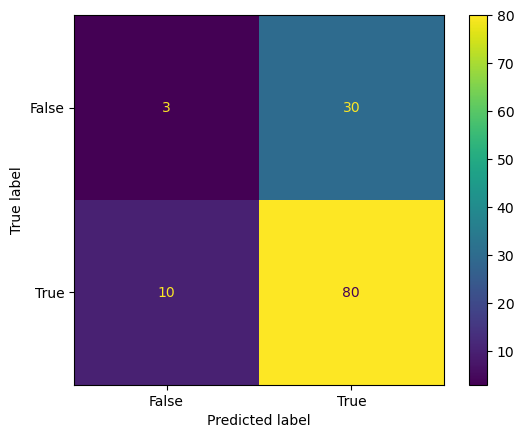

True negative: 3
False postive: 30
False negative: 10
True postive: 80


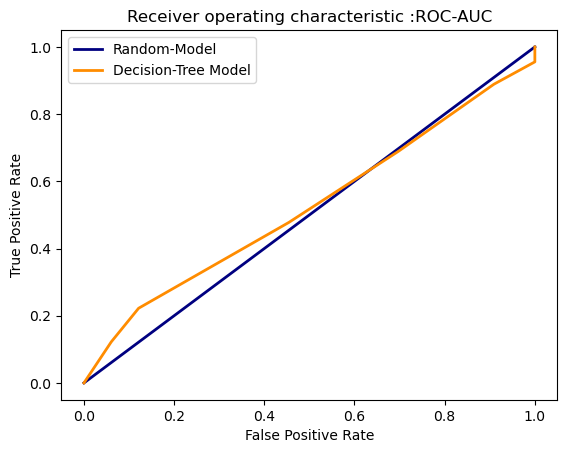

Computed Area Under the Curve (AUC) 0.5234006734006733


In [521]:
# ============================= Predictions ============================================================

y_pred_dt=grid_search.best_estimator_.predict(X_test)

# ============================ Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=grid_search.best_estimator_.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Decision-Tree Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [523]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
knn_tune = pd.DataFrame(data,
                  index = idx,
                  columns=['Hyper Tune Model'])
knn_tune

,Hyper Tune Model
Accuracy,67.48
f1,0.80
Precision,0.73
Recall,0.89


In [553]:
compaire_df = pd.concat([knn_base,knn_tune],axis=1)
compaire_df

,Base Model,Hyper Tune Model
Accuracy,62.60,67.48
f1,0.76,0.80
Precision,0.72,0.73
Recall,0.79,0.89


## NB

In [528]:
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.naive_bayes import GaussianNB
GB=GaussianNB()   # Base model
GB

GaussianNB()

In [530]:
GB_fit = GB.fit(X_train,y_train)
GB_fit

GaussianNB()

In [532]:
GB.get_params()

{'priors': None, 'var_smoothing': 1e-09}

In [534]:
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]  # 4 values
}

In [536]:
grid_search = GridSearchCV(GB,
                           param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=True)

grid_search 

GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06]},
             scoring='accuracy', verbose=True)

In [538]:
grid_search.fit(X_train,y_train) 

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06]},
             scoring='accuracy', verbose=True)

In [540]:
grid_search.best_estimator_ 

GaussianNB(var_smoothing=1e-07)

In [542]:
grid_search.best_score_

0.6639043496186354

In [544]:
grid_search.best_params_

{'var_smoothing': 1e-07}

**BY Base Model**

accuray is: 70.73
F1 is: 0.82
Precision is: 0.74
Recall is: 0.92
              precision    recall  f1-score   support

           0       0.36      0.12      0.18        33
           1       0.74      0.92      0.82        90

    accuracy                           0.71       123
   macro avg       0.55      0.52      0.50       123
weighted avg       0.64      0.71      0.65       123



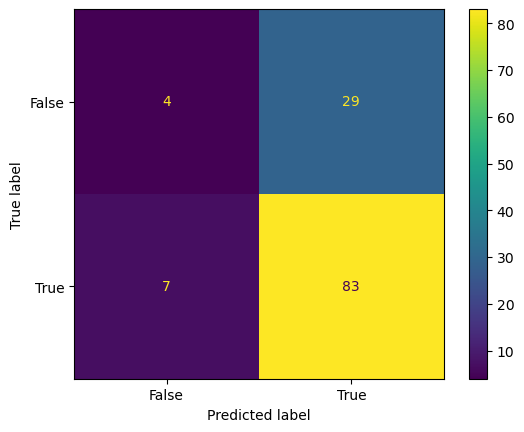

True negative: 4
False postive: 29
False negative: 7
True postive: 83


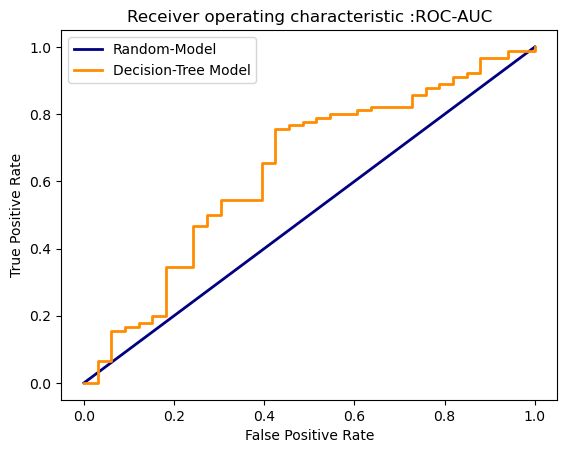

Computed Area Under the Curve (AUC) 0.6377104377104376


In [547]:
# =============================  Predictions ============================================================

y_pred_dt=GB_fit.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix  =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=GB_fit.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Decision-Tree Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [549]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
nb_base = pd.DataFrame(data,
                  index = idx,
                  columns=['Base Model'])
nb_base

,Base Model
Accuracy,70.73
f1,0.82
Precision,0.74
Recall,0.92


**BY Hyper Tune**

accuray is: 72.36
F1 is: 0.84
Precision is: 0.73
Recall is: 0.99
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
           1       0.73      0.99      0.84        90

    accuracy                           0.72       123
   macro avg       0.36      0.49      0.42       123
weighted avg       0.53      0.72      0.61       123



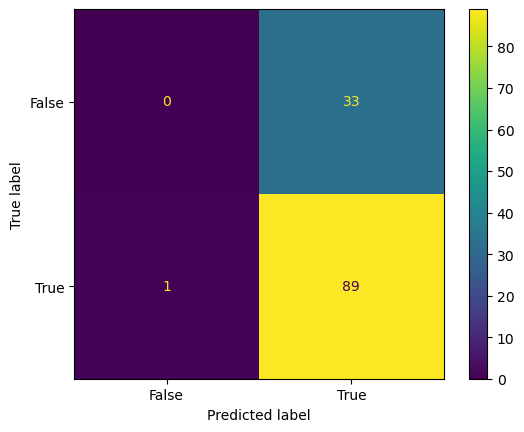

True negative: 0
False postive: 33
False negative: 1
True postive: 89


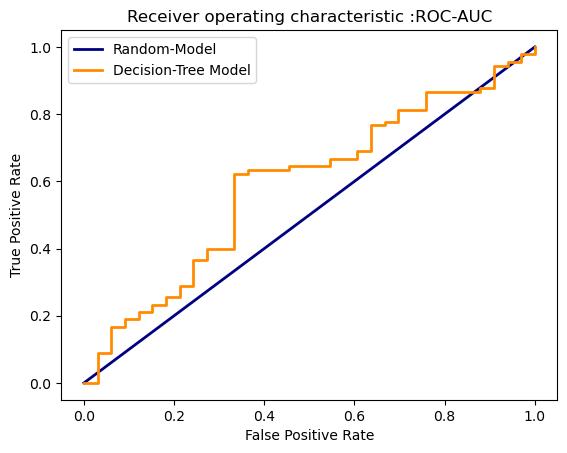

Computed Area Under the Curve (AUC) 0.5898989898989898


In [556]:
# ============================= Predictions ============================================================

y_pred_dt=grid_search.best_estimator_.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=grid_search.best_estimator_.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Decision-Tree Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [558]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
nb_tune = pd.DataFrame(data,
                  index = idx,
                  columns=['Hyper Tune Model'])
nb_tune

,Hyper Tune Model
Accuracy,72.36
f1,0.84
Precision,0.73
Recall,0.99


In [560]:
compaire_df = pd.concat([nb_base,nb_tune],axis=1)
compaire_df

,Base Model,Hyper Tune Model
Accuracy,70.73,72.36
f1,0.82,0.84
Precision,0.74,0.73
Recall,0.92,0.99


## Logistic Regression

In [563]:
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression()   # Base model
LR

LogisticRegression()

In [565]:
LR_fit = LR.fit(X_train,y_train)
LR_fit

LogisticRegression()

In [567]:
LR.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [569]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],        
    'penalty': ['l2'],             
    'solver': ['lbfgs']             
}

In [571]:
grid_search = GridSearchCV(LR,
                           param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=True)

grid_search

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='accuracy', verbose=True)

In [573]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='accuracy', verbose=True)

In [575]:
grid_search.best_estimator_ 

LogisticRegression(C=0.1)

In [577]:
grid_search.best_score_

0.6782106782106783

In [579]:
grid_search.best_params_

{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}

**BY Base Model**

accuray is: 73.98
F1 is: 0.85
Precision is: 0.74
Recall is: 0.99
              precision    recall  f1-score   support

           0       0.67      0.06      0.11        33
           1       0.74      0.99      0.85        90

    accuracy                           0.74       123
   macro avg       0.70      0.52      0.48       123
weighted avg       0.72      0.74      0.65       123



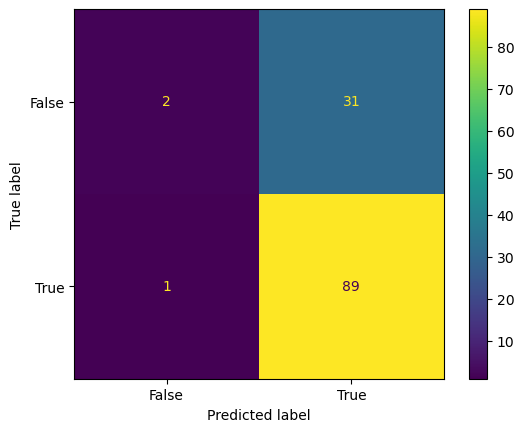

True negative: 2
False postive: 31
False negative: 1
True postive: 89


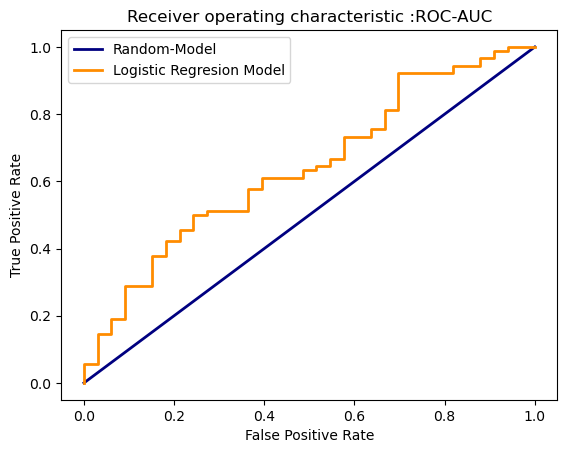

Computed Area Under the Curve (AUC) 0.6417508417508417


In [582]:
# ============================= Predictions ============================================================

y_pred_dt=LR_fit.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#===================================== ROC-AUC curve ================================================================

y_dt_pred_prob=LR_fit.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Logistic Regresion Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [584]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
log_base = pd.DataFrame(data,
                  index = idx,
                  columns=['Base Model'])
log_base

,Base Model
Accuracy,73.98
f1,0.85
Precision,0.74
Recall,0.99


**BY Hyper Tune**

accuray is: 73.17
F1 is: 0.85
Precision is: 0.73
Recall is: 1.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
           1       0.73      1.00      0.85        90

    accuracy                           0.73       123
   macro avg       0.37      0.50      0.42       123
weighted avg       0.54      0.73      0.62       123



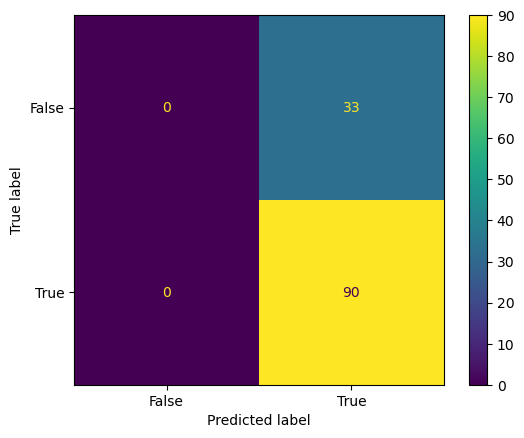

True negative: 0
False postive: 33
False negative: 0
True postive: 90


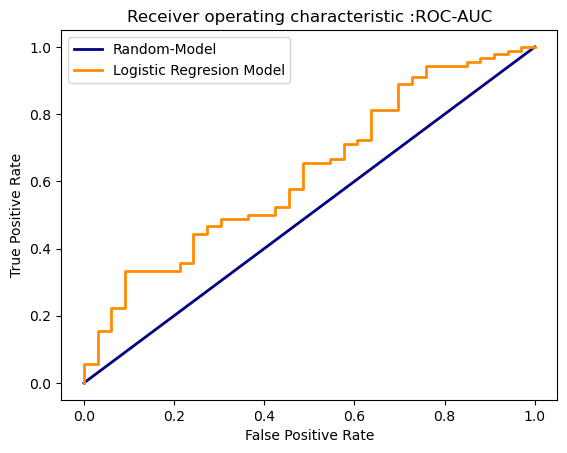

Computed Area Under the Curve (AUC) 0.6262626262626263


In [587]:
# =============================  Predictions ============================================================

y_pred_dt=grid_search.best_estimator_.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# =============================== Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=grid_search.best_estimator_.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Logistic Regresion Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [589]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
log_tune = pd.DataFrame(data,
                  index = idx,
                  columns=['Hyper Tune Model'])
log_tune

,Hyper Tune Model
Accuracy,73.17
f1,0.85
Precision,0.73
Recall,1.00


In [591]:
compaire_df = pd.concat([log_base,log_tune],axis=1)
compaire_df

,Base Model,Hyper Tune Model
Accuracy,73.98,73.17
f1,0.85,0.85
Precision,0.74,0.73
Recall,0.99,1.00


## Decision Tree

In [594]:
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.tree import DecisionTreeClassifier
grid_tree=DecisionTreeClassifier()   # Base model
grid_tree

DecisionTreeClassifier()

In [596]:
grid_tree_fit = grid_tree.fit(X_train,y_train)
grid_tree_fit

DecisionTreeClassifier()

In [598]:
grid_tree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [602]:
param_grid = {
    "criterion":['gini','entropy'], 
    'max_depth': [3, 4, 5, 6, 7, 8], 
    'min_samples_split': [2, 3, 4],  
    'min_samples_leaf': [1, 2, 3, 4], 
    'random_state': [0, 42] 
}

In [604]:
grid_search = GridSearchCV(grid_tree,  # Base model
                           param_grid, # params 
                           scoring='accuracy', # metric
                           cv=5,
                           verbose=True)

grid_search

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 3, 4],
                         'random_state': [0, 42]},
             scoring='accuracy', verbose=True)

In [606]:
grid_search.fit(X_train,y_train)  

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 3, 4],
                         'random_state': [0, 42]},
             scoring='accuracy', verbose=True)

In [608]:
grid_search.best_estimator_  

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [610]:
grid_search.best_score_

0.6517625231910946

In [612]:
grid_search.best_params_

{'criterion': 'entropy',
 'max_depth': 3,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'random_state': 0}

**BY Base Model**

accuray is: 56.1
F1 is: 0.68
Precision is: 0.72
Recall is: 0.64
              precision    recall  f1-score   support

           0       0.26      0.33      0.29        33
           1       0.72      0.64      0.68        90

    accuracy                           0.56       123
   macro avg       0.49      0.49      0.49       123
weighted avg       0.60      0.56      0.58       123



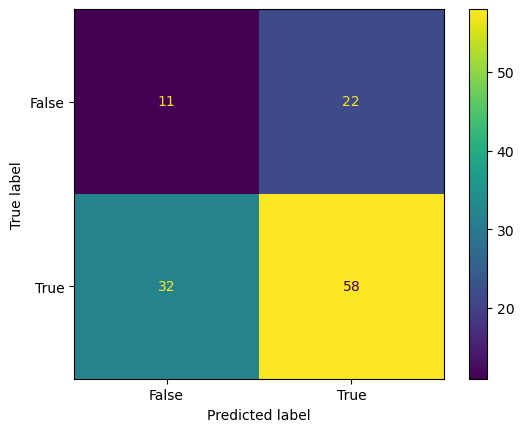

True negative: 11
False postive: 22
False negative: 32
True postive: 58


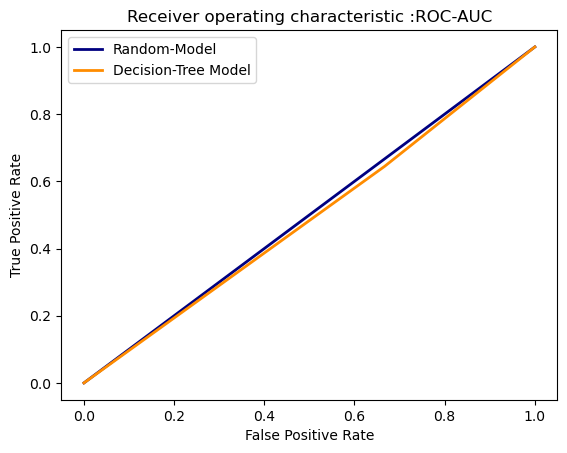

Computed Area Under the Curve (AUC) 0.48888888888888893


In [615]:
# ============================  Predictions ============================================================

y_pred_dt=grid_tree_fit.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=grid_tree_fit.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Decision-Tree Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [617]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
tree_base = pd.DataFrame(data,
                  index = idx,
                  columns=['Base Model'])
tree_base

,Base Model
Accuracy,56.10
f1,0.68
Precision,0.72
Recall,0.64


**BY Hyper Tune**

accuray is: 73.98
F1 is: 0.85
Precision is: 0.74
Recall is: 1.0
              precision    recall  f1-score   support

           0       1.00      0.03      0.06        33
           1       0.74      1.00      0.85        90

    accuracy                           0.74       123
   macro avg       0.87      0.52      0.45       123
weighted avg       0.81      0.74      0.64       123



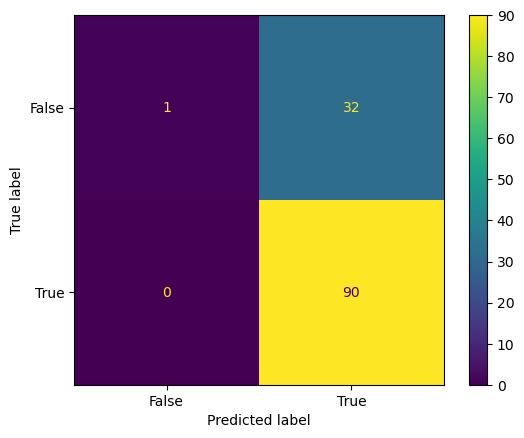

True negative: 1
False postive: 32
False negative: 0
True postive: 90


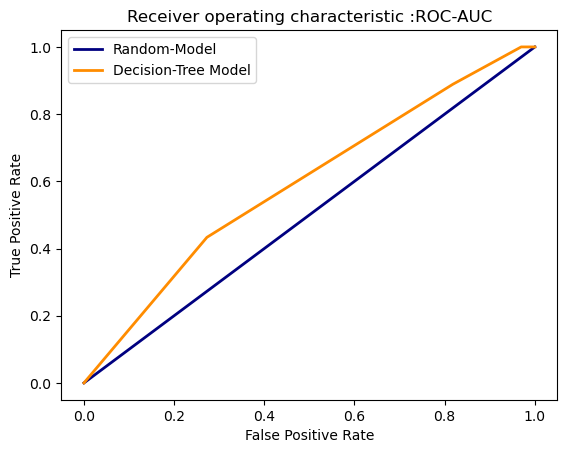

Computed Area Under the Curve (AUC) 0.5930976430976431


In [620]:
# ============================= Predictions ============================================================

y_pred_dt=grid_search.best_estimator_.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#=======================================  ROC-AUC curve ================================================================

y_dt_pred_prob=grid_search.best_estimator_.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Decision-Tree Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [622]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
tree_tune = pd.DataFrame(data,
                  index = idx,
                  columns=['Hyper Tune Model'])
tree_tune

,Hyper Tune Model
Accuracy,73.98
f1,0.85
Precision,0.74
Recall,1.00


In [624]:
compaired_df = pd.concat([tree_base,tree_tune],axis=1)
compaired_df

,Base Model,Hyper Tune Model
Accuracy,56.10,73.98
f1,0.68,0.85
Precision,0.72,0.74
Recall,0.64,1.00


## Random Forest

In [628]:
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.ensemble import RandomForestClassifier
RF=RandomForestClassifier()   # Base model
RF

RandomForestClassifier()

In [630]:
RF_fit = RF.fit(X_train,y_train)
RF_fit

RandomForestClassifier()

In [632]:
RF.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [634]:
param_grid = {
    'n_estimators': [50, 100, 200],        
    'max_depth': [None, 5, 10, 20],         
    'min_samples_split': [2, 5, 10],      
    'min_samples_leaf': [1, 2, 4],         
    'bootstrap': [True, False]              
}


In [638]:
grid_search = GridSearchCV(RF,
                           param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=True)

grid_search

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=True)

In [640]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=True)

In [644]:
grid_search.best_estimator_ 

RandomForestClassifier(max_depth=20, min_samples_split=5)

In [646]:
grid_search.best_score_

0.6862914862914863

In [648]:
grid_search.best_params_

{'bootstrap': True,
 'max_depth': 20,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}

**BY Base Model**

accuray is: 66.67
F1 is: 0.79
Precision is: 0.73
Recall is: 0.86
              precision    recall  f1-score   support

           0       0.28      0.15      0.20        33
           1       0.73      0.86      0.79        90

    accuracy                           0.67       123
   macro avg       0.51      0.50      0.49       123
weighted avg       0.61      0.67      0.63       123



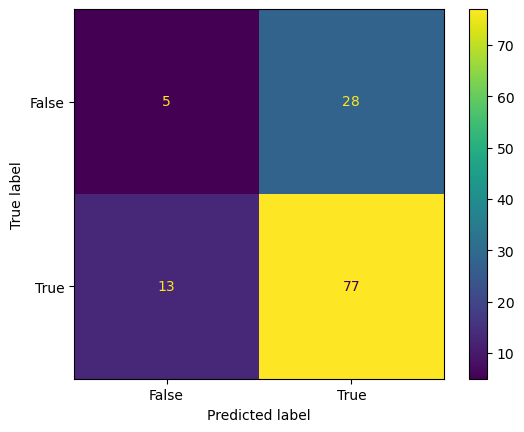

True negative: 5
False postive: 28
False negative: 13
True postive: 77


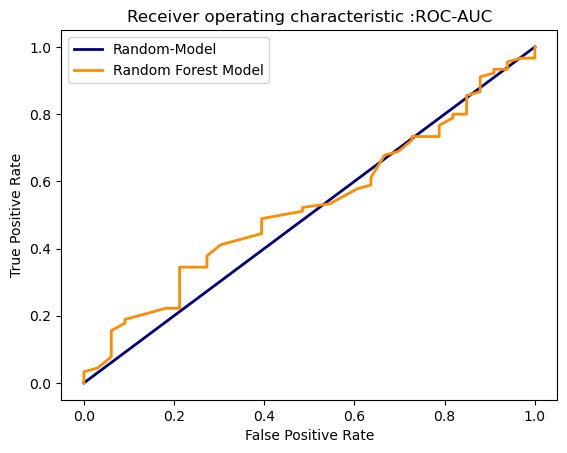

Computed Area Under the Curve (AUC) 0.5284511784511784


In [651]:
# ============================= Predictions ============================================================

y_pred_dt=RF_fit.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#===================================== ROC-AUC curve ================================================================

y_dt_pred_prob=RF_fit.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Random Forest Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [652]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
rf_base = pd.DataFrame(data,
                  index = idx,
                  columns=['Base Model'])
rf_base

,Base Model
Accuracy,66.67
f1,0.79
Precision,0.73
Recall,0.86


**BY Hyper Tune**

accuray is: 67.48
F1 is: 0.8
Precision is: 0.73
Recall is: 0.89
              precision    recall  f1-score   support

           0       0.23      0.09      0.13        33
           1       0.73      0.89      0.80        90

    accuracy                           0.67       123
   macro avg       0.48      0.49      0.47       123
weighted avg       0.59      0.67      0.62       123



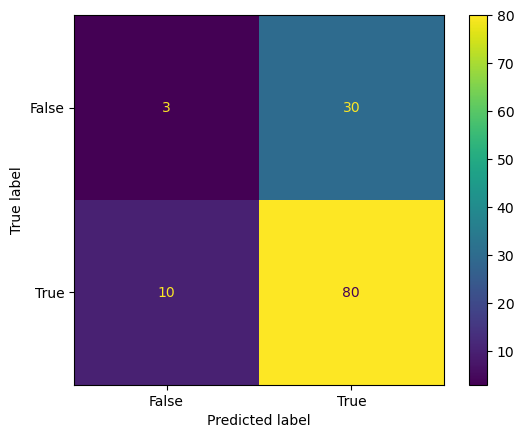

True negative: 3
False postive: 30
False negative: 10
True postive: 80


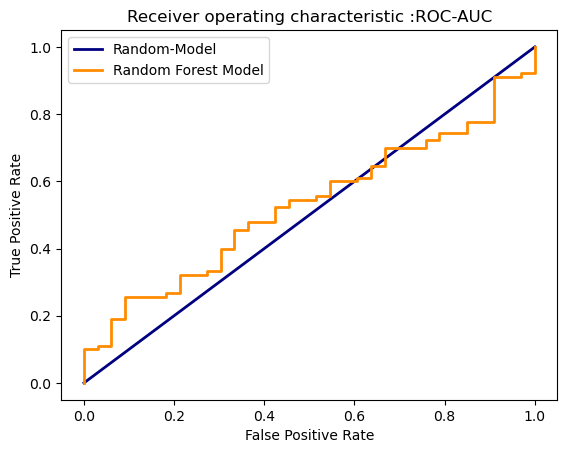

Computed Area Under the Curve (AUC) 0.528956228956229


In [656]:
# =============================  Predictions ============================================================

y_pred_dt=grid_search.best_estimator_.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# =============================== Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=grid_search.best_estimator_.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Random Forest Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [657]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
rf_tune = pd.DataFrame(data,
                  index = idx,
                  columns=['Hyper Tune Model'])
rf_tune

,Hyper Tune Model
Accuracy,67.48
f1,0.80
Precision,0.73
Recall,0.89


In [660]:
compaire_df = pd.concat([rf_base,rf_tune],axis=1)
compaire_df

,Base Model,Hyper Tune Model
Accuracy,66.67,67.48
f1,0.79,0.80
Precision,0.73,0.73
Recall,0.86,0.89


# Data2

In [692]:
x2 = data2.drop(['Loan_ID','Loan_Status'],axis=1)
y2 = data2['Loan_Status']

In [694]:
X_train, X_test, y_train, y_test = train_test_split(x2,y2, test_size=0.2,random_state=0)


In [696]:
print(X_train.shape),
print(X_test.shape),
print(y_train.shape),
print(y_test.shape)

(491, 12)
(123, 12)
(491,)
(123,)


## KNN

In [699]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()   # Base model
knn

KNeighborsClassifier()

In [701]:
knn_fit = knn.fit(X_train,y_train) 
knn_fit

KNeighborsClassifier()

In [703]:
knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [705]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9],       
    'weights': ['uniform', 'distance'],  
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],  
    'p': [1, 2],  
}

In [707]:
grid_search = GridSearchCV(knn,  # Base model
                           param_grid, # params 
                           scoring='accuracy', # metric
                           cv=5,
                           verbose=True)

grid_search

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [3, 5, 7, 9], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=True)

In [709]:
grid_search.fit(X_train,y_train) 

Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [3, 5, 7, 9], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=True)

In [711]:
grid_search.best_estimator_ 

KNeighborsClassifier(weights='distance')

In [713]:
grid_search.best_score_

0.6517006802721088

In [715]:
grid_search.best_params_

{'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'distance'}

**BY Base Model**

accuray is: 67.48
F1 is: 0.8
Precision is: 0.73
Recall is: 0.88
              precision    recall  f1-score   support

           0       0.27      0.12      0.17        33
           1       0.73      0.88      0.80        90

    accuracy                           0.67       123
   macro avg       0.50      0.50      0.48       123
weighted avg       0.61      0.67      0.63       123



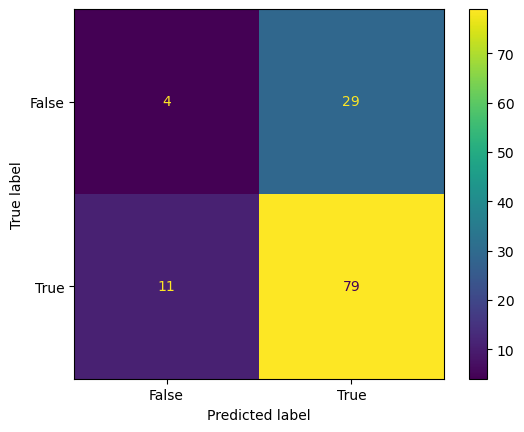

True negative: 4
False postive: 29
False negative: 11
True postive: 79


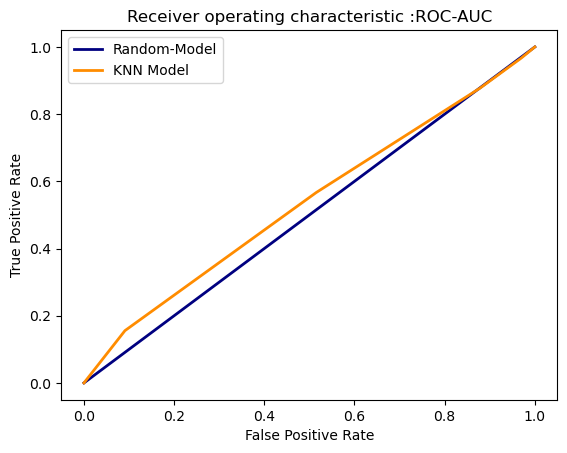

Computed Area Under the Curve (AUC) 0.5365319865319865


In [720]:
# ============================= Predictions ============================================================

y_pred_dt=knn_fit.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=knn_fit.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="KNN Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [722]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
knn_base = pd.DataFrame(data,
                  index = idx,
                  columns=['Base Model'])
knn_base

,Base Model
Accuracy,67.48
f1,0.80
Precision,0.73
Recall,0.88


**BY Hyper Tune**

accuray is: 67.48
F1 is: 0.8
Precision is: 0.73
Recall is: 0.88
              precision    recall  f1-score   support

           0       0.27      0.12      0.17        33
           1       0.73      0.88      0.80        90

    accuracy                           0.67       123
   macro avg       0.50      0.50      0.48       123
weighted avg       0.61      0.67      0.63       123



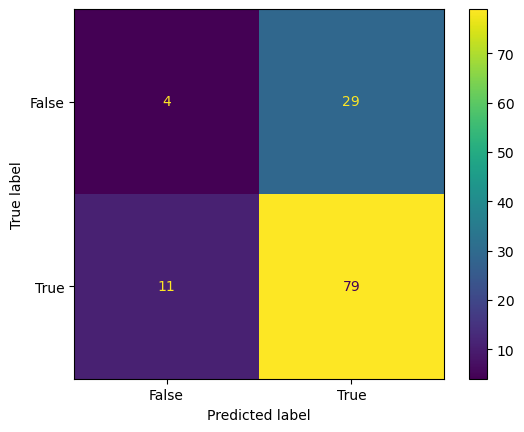

True negative: 4
False postive: 29
False negative: 11
True postive: 79


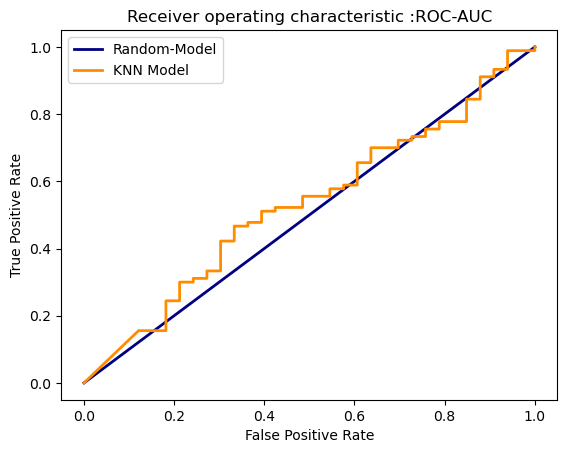

Computed Area Under the Curve (AUC) 0.5303030303030303


In [727]:
# ============================= Predictions ============================================================

y_pred_dt=grid_search.best_estimator_.predict(X_test)

# ============================ Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=grid_search.best_estimator_.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="KNN Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [729]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
knn_tune = pd.DataFrame(data,
                  index = idx,
                  columns=['Hyper Tune Model'])
knn_tune

,Hyper Tune Model
Accuracy,67.48
f1,0.80
Precision,0.73
Recall,0.88


In [731]:
compaire_df = pd.concat([knn_base,knn_tune],axis=1)
compaire_df

,Base Model,Hyper Tune Model
Accuracy,67.48,67.48
f1,0.80,0.80
Precision,0.73,0.73
Recall,0.88,0.88


## NB

In [735]:
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.naive_bayes import GaussianNB
GB=GaussianNB()   # Base model
GB

GaussianNB()

In [737]:
GB_fit = GB.fit(X_train,y_train)
GB_fit

GaussianNB()

In [739]:
GB.get_params()

{'priors': None, 'var_smoothing': 1e-09}

In [741]:
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]  # 4 values
}

In [743]:
grid_search = GridSearchCV(GB,
                           param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=True)

grid_search 

GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06]},
             scoring='accuracy', verbose=True)

In [745]:
grid_search.fit(X_train,y_train) 

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06]},
             scoring='accuracy', verbose=True)

In [747]:
grid_search.best_estimator_ 

GaussianNB()

In [749]:
grid_search.best_score_

0.6456606885178313

In [751]:
grid_search.best_params_

{'var_smoothing': 1e-09}

**BY Base Model**

accuray is: 70.73
F1 is: 0.82
Precision is: 0.75
Recall is: 0.91
              precision    recall  f1-score   support

           0       0.38      0.15      0.22        33
           1       0.75      0.91      0.82        90

    accuracy                           0.71       123
   macro avg       0.57      0.53      0.52       123
weighted avg       0.65      0.71      0.66       123



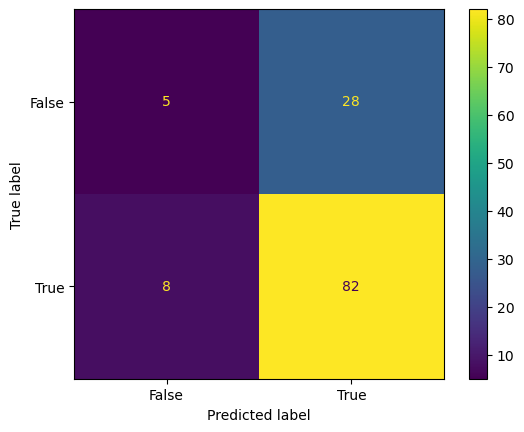

True negative: 5
False postive: 28
False negative: 8
True postive: 82


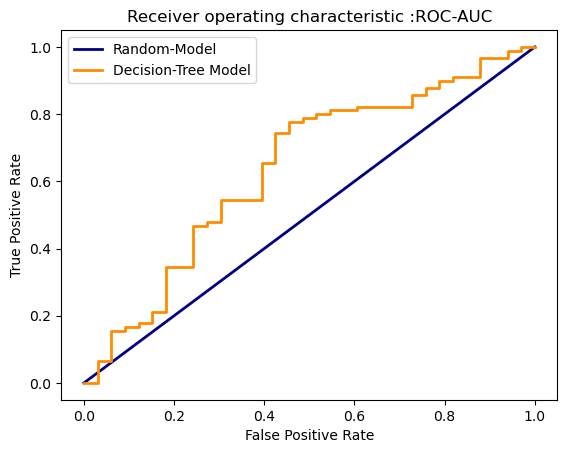

Computed Area Under the Curve (AUC) 0.6393939393939394


In [754]:
# =============================  Predictions ============================================================

y_pred_dt=GB_fit.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix  =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=GB_fit.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Decision-Tree Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [756]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
nb_base = pd.DataFrame(data,
                  index = idx,
                  columns=['Base Model'])
nb_base

,Base Model
Accuracy,70.73
f1,0.82
Precision,0.75
Recall,0.91


**BY Hyper Tune**

accuray is: 70.73
F1 is: 0.82
Precision is: 0.75
Recall is: 0.91
              precision    recall  f1-score   support

           0       0.38      0.15      0.22        33
           1       0.75      0.91      0.82        90

    accuracy                           0.71       123
   macro avg       0.57      0.53      0.52       123
weighted avg       0.65      0.71      0.66       123



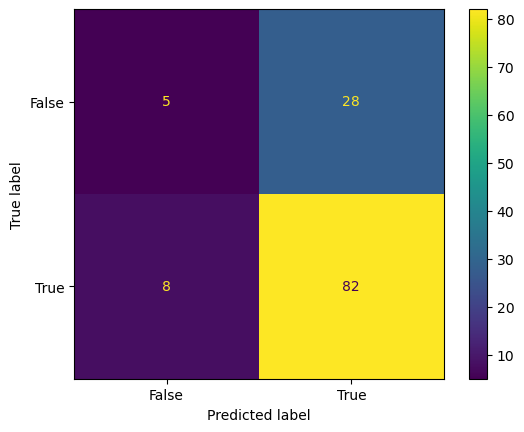

True negative: 5
False postive: 28
False negative: 8
True postive: 82


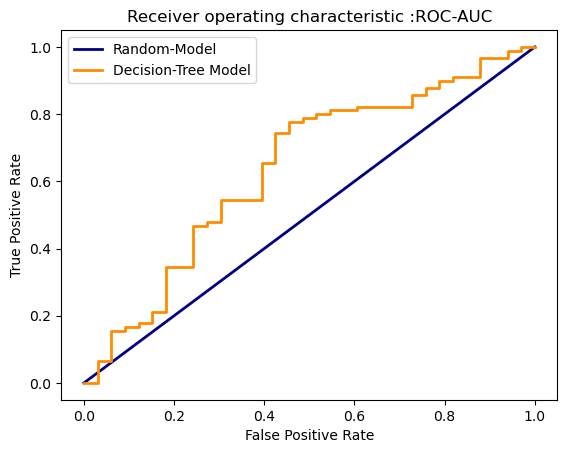

Computed Area Under the Curve (AUC) 0.6393939393939394


In [759]:
# ============================= Predictions ============================================================

y_pred_dt=grid_search.best_estimator_.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=grid_search.best_estimator_.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Decision-Tree Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [761]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
nb_tune = pd.DataFrame(data,
                  index = idx,
                  columns=['Hyper Tune Model'])
nb_tune

,Hyper Tune Model
Accuracy,70.73
f1,0.82
Precision,0.75
Recall,0.91


In [763]:
compaire_df = pd.concat([nb_base,nb_tune],axis=1)
compaire_df

,Base Model,Hyper Tune Model
Accuracy,70.73,70.73
f1,0.82,0.82
Precision,0.75,0.75
Recall,0.91,0.91


## Logistic Regression

In [766]:
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression()   # Base model
LR

LogisticRegression()

In [768]:
LR_fit = LR.fit(X_train,y_train)
LR_fit

LogisticRegression()

In [770]:
LR.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [772]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],        
    'penalty': ['l2'],             
    'solver': ['lbfgs']             
}

In [774]:
grid_search = GridSearchCV(LR,
                           param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=True)

grid_search

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='accuracy', verbose=True)

In [776]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='accuracy', verbose=True)

In [778]:
grid_search.best_estimator_ 

LogisticRegression(C=0.01)

In [780]:
grid_search.best_score_

0.6761698618841476

In [782]:
grid_search.best_params_

{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}

**BY Base Model**

accuray is: 71.54
F1 is: 0.83
Precision is: 0.73
Recall is: 0.97
              precision    recall  f1-score   support

           0       0.25      0.03      0.05        33
           1       0.73      0.97      0.83        90

    accuracy                           0.72       123
   macro avg       0.49      0.50      0.44       123
weighted avg       0.60      0.72      0.62       123



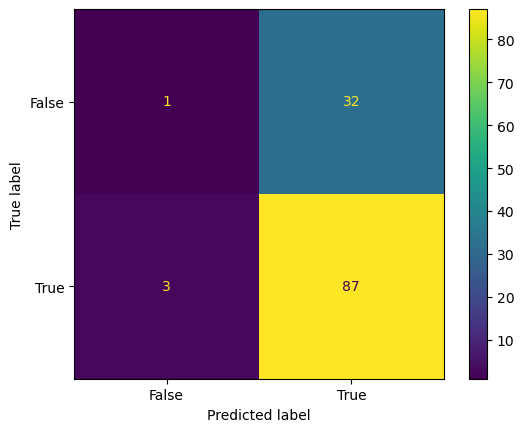

True negative: 1
False postive: 32
False negative: 3
True postive: 87


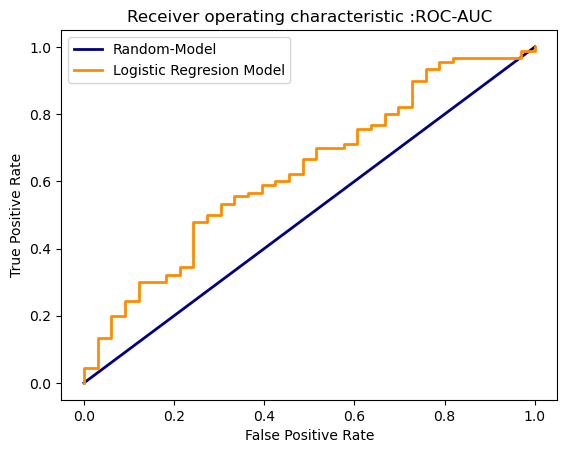

Computed Area Under the Curve (AUC) 0.6323232323232324


In [785]:
# ============================= Predictions ============================================================

y_pred_dt=LR_fit.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#===================================== ROC-AUC curve ================================================================

y_dt_pred_prob=LR_fit.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Logistic Regresion Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [787]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
log_base = pd.DataFrame(data,
                  index = idx,
                  columns=['Base Model'])
log_base

,Base Model
Accuracy,71.54
f1,0.83
Precision,0.73
Recall,0.97


**BY Hyper Tune**

accuray is: 73.17
F1 is: 0.85
Precision is: 0.73
Recall is: 1.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
           1       0.73      1.00      0.85        90

    accuracy                           0.73       123
   macro avg       0.37      0.50      0.42       123
weighted avg       0.54      0.73      0.62       123



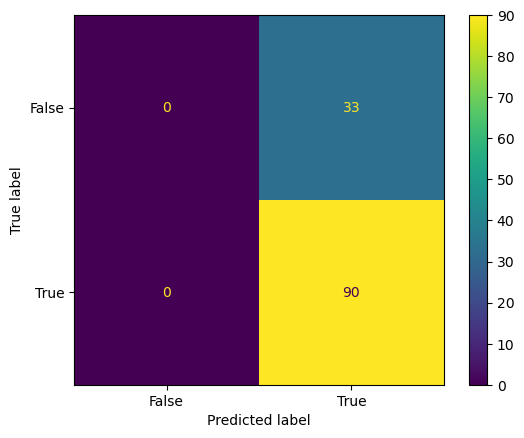

True negative: 0
False postive: 33
False negative: 0
True postive: 90


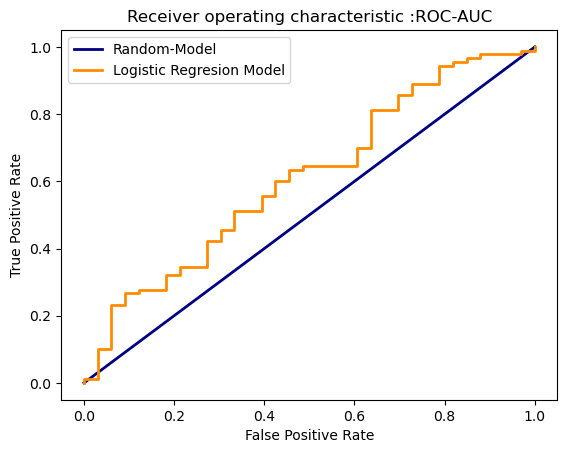

Computed Area Under the Curve (AUC) 0.6117845117845118


In [790]:
# =============================  Predictions ============================================================

y_pred_dt=grid_search.best_estimator_.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# =============================== Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=grid_search.best_estimator_.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Logistic Regresion Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [792]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
log_tune = pd.DataFrame(data,
                  index = idx,
                  columns=['Hyper Tune Model'])
log_tune

,Hyper Tune Model
Accuracy,73.17
f1,0.85
Precision,0.73
Recall,1.00


In [794]:
compaire_df = pd.concat([log_base,log_tune],axis=1)
compaire_df

,Base Model,Hyper Tune Model
Accuracy,71.54,73.17
f1,0.83,0.85
Precision,0.73,0.73
Recall,0.97,1.00


## Decision Tree

In [798]:
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.tree import DecisionTreeClassifier
grid_tree=DecisionTreeClassifier()   # Base model
grid_tree

DecisionTreeClassifier()

In [800]:
grid_tree_fit = grid_tree.fit(X_train,y_train)
grid_tree_fit

DecisionTreeClassifier()

In [802]:
param_grid = {
    "criterion":['gini','entropy'], 
    'max_depth': [3, 4, 5, 6, 7, 8], 
    'min_samples_split': [2, 3, 4],  
    'min_samples_leaf': [1, 2, 3, 4], 
    'random_state': [0, 42] 
}

In [804]:
grid_search = GridSearchCV(grid_tree,  # Base model
                           param_grid, # params 
                           scoring='accuracy', # metric
                           cv=5,
                           verbose=True)

grid_search

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 3, 4],
                         'random_state': [0, 42]},
             scoring='accuracy', verbose=True)

In [806]:
grid_search.fit(X_train,y_train)  

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 3, 4],
                         'random_state': [0, 42]},
             scoring='accuracy', verbose=True)

In [808]:
grid_search.best_estimator_  

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [810]:
grid_search.best_score_

0.6517625231910946

In [812]:
grid_search.best_params_

{'criterion': 'entropy',
 'max_depth': 3,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'random_state': 0}

**BY Base Model**

accuray is: 54.47
F1 is: 0.68
Precision is: 0.7
Recall is: 0.66
              precision    recall  f1-score   support

           0       0.21      0.24      0.22        33
           1       0.70      0.66      0.68        90

    accuracy                           0.54       123
   macro avg       0.45      0.45      0.45       123
weighted avg       0.57      0.54      0.56       123



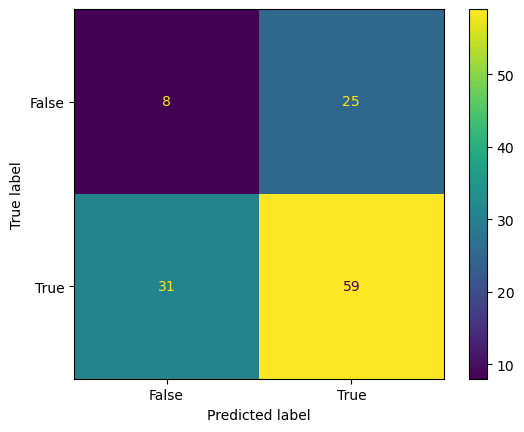

True negative: 8
False postive: 25
False negative: 31
True postive: 59


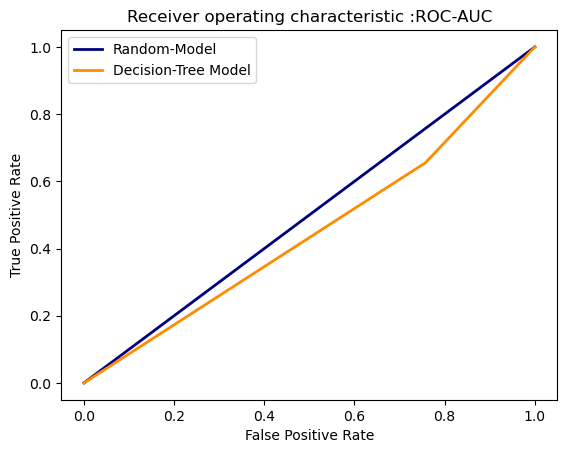

Computed Area Under the Curve (AUC) 0.448989898989899


In [815]:
# ============================  Predictions ============================================================

y_pred_dt=grid_tree_fit.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=grid_tree_fit.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Decision-Tree Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [817]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
tree_base = pd.DataFrame(data,
                  index = idx,
                  columns=['Base Model'])
tree_base

,Base Model
Accuracy,54.47
f1,0.68
Precision,0.70
Recall,0.66


**BY Hyper Tune**

accuray is: 73.98
F1 is: 0.85
Precision is: 0.74
Recall is: 1.0
              precision    recall  f1-score   support

           0       1.00      0.03      0.06        33
           1       0.74      1.00      0.85        90

    accuracy                           0.74       123
   macro avg       0.87      0.52      0.45       123
weighted avg       0.81      0.74      0.64       123



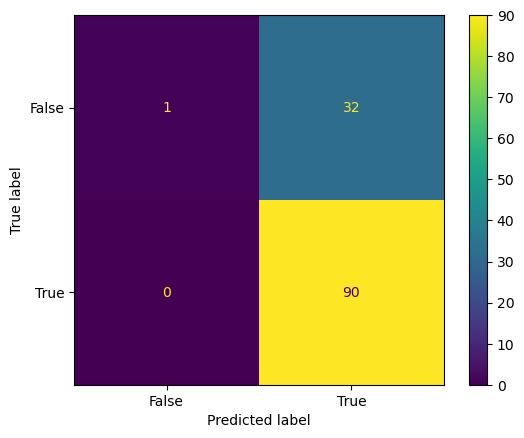

True negative: 1
False postive: 32
False negative: 0
True postive: 90


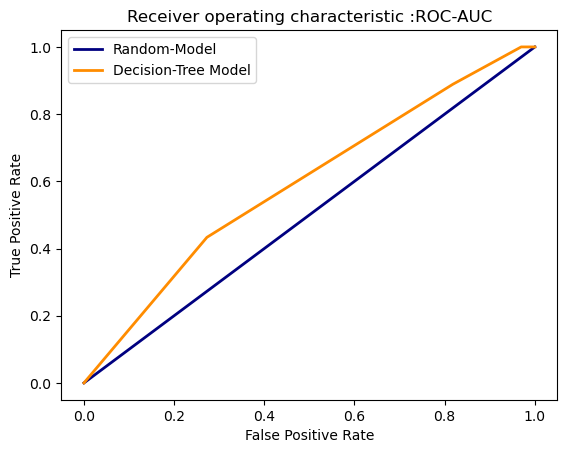

Computed Area Under the Curve (AUC) 0.5930976430976431


In [820]:
# ============================= Predictions ============================================================

y_pred_dt=grid_search.best_estimator_.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#=======================================  ROC-AUC curve ================================================================

y_dt_pred_prob=grid_search.best_estimator_.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Decision-Tree Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [822]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
tree_tune = pd.DataFrame(data,
                  index = idx,
                  columns=['Hyper Tune Model'])
tree_tune

,Hyper Tune Model
Accuracy,73.98
f1,0.85
Precision,0.74
Recall,1.00


In [824]:
compaired_df = pd.concat([tree_base,tree_tune],axis=1)
compaired_df

,Base Model,Hyper Tune Model
Accuracy,54.47,73.98
f1,0.68,0.85
Precision,0.70,0.74
Recall,0.66,1.00


## Random Forest

In [827]:
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.ensemble import RandomForestClassifier
RF=RandomForestClassifier()   # Base model
RF

RandomForestClassifier()

In [829]:
RF_fit = RF.fit(X_train,y_train)
RF_fit

RandomForestClassifier()

In [831]:
param_grid = {
    'n_estimators': [50, 100, 200],        
    'max_depth': [None, 5, 10, 20],         
    'min_samples_split': [2, 5, 10],      
    'min_samples_leaf': [1, 2, 4],         
    'bootstrap': [True, False]              
}


In [833]:
grid_search = GridSearchCV(RF,
                           param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=True)

grid_search

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=True)

In [835]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=True)

In [838]:
grid_search.best_estimator_ 

RandomForestClassifier(max_depth=5, min_samples_leaf=4, n_estimators=50)

In [836]:
grid_search.best_score_

0.6761698618841476

In [837]:
grid_search.best_params_

{'bootstrap': True,
 'max_depth': 5,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'n_estimators': 50}

**BY Base Model**

accuray is: 69.11
F1 is: 0.81
Precision is: 0.75
Recall is: 0.88
              precision    recall  f1-score   support

           0       0.35      0.18      0.24        33
           1       0.75      0.88      0.81        90

    accuracy                           0.69       123
   macro avg       0.55      0.53      0.52       123
weighted avg       0.64      0.69      0.65       123



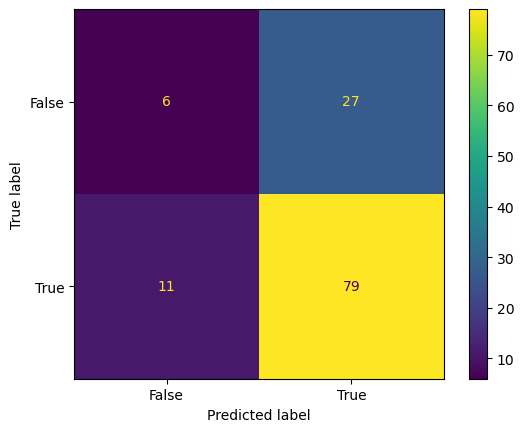

True negative: 6
False postive: 27
False negative: 11
True postive: 79


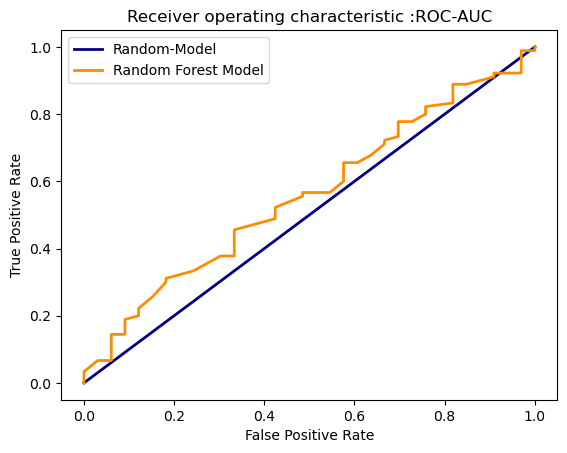

Computed Area Under the Curve (AUC) 0.5577441077441078


In [845]:
# ============================= Predictions ============================================================

y_pred_dt=RF_fit.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#===================================== ROC-AUC curve ================================================================

y_dt_pred_prob=RF_fit.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Random Forest Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [847]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
rf_base = pd.DataFrame(data,
                  index = idx,
                  columns=['Base Model'])
rf_base

,Base Model
Accuracy,69.11
f1,0.81
Precision,0.75
Recall,0.88


**BY Hyper Tune**

accuray is: 73.98
F1 is: 0.85
Precision is: 0.74
Recall is: 1.0
              precision    recall  f1-score   support

           0       1.00      0.03      0.06        33
           1       0.74      1.00      0.85        90

    accuracy                           0.74       123
   macro avg       0.87      0.52      0.45       123
weighted avg       0.81      0.74      0.64       123



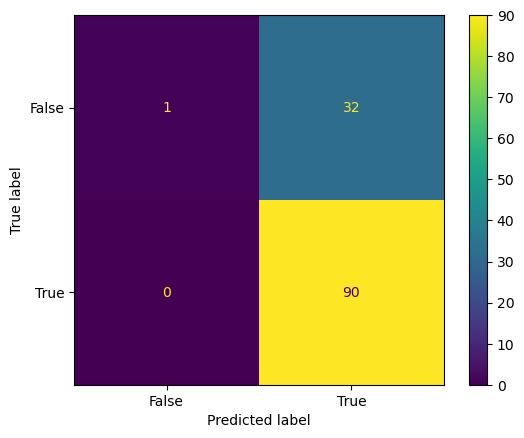

True negative: 1
False postive: 32
False negative: 0
True postive: 90


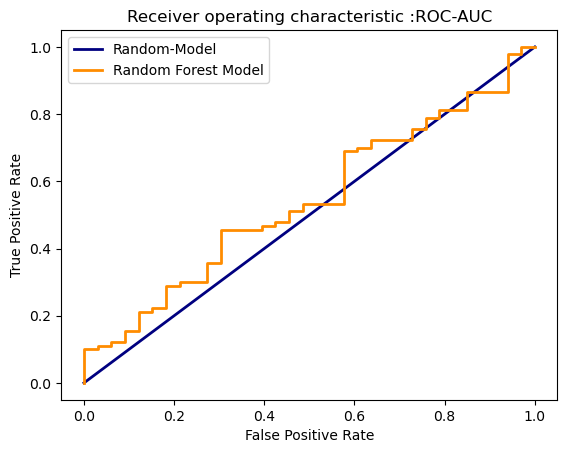

Computed Area Under the Curve (AUC) 0.5420875420875421


In [850]:
# =============================  Predictions ============================================================

y_pred_dt=grid_search.best_estimator_.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# =============================== Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=grid_search.best_estimator_.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Random Forest Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [851]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
rf_tune = pd.DataFrame(data,
                  index = idx,
                  columns=['Hyper Tune Model'])
rf_tune

,Hyper Tune Model
Accuracy,73.98
f1,0.85
Precision,0.74
Recall,1.00


In [854]:
compaire_df = pd.concat([rf_base,rf_tune],axis=1)
compaire_df

,Base Model,Hyper Tune Model
Accuracy,69.11,73.98
f1,0.81,0.85
Precision,0.75,0.74
Recall,0.88,1.00


# Data3

In [860]:
data3

,PC1,PC2,PC3,PC4,PC5,PC6,Loan_Status
0,-0.129285,-1.053501,-0.838852,0.726940,-0.158247,0.233735,1
1,0.011738,0.074218,0.319539,0.106699,0.196725,-0.263747,0
2,-1.488160,-0.828097,-0.172697,0.755332,0.133320,-0.533247,1
3,-0.964089,0.784134,-0.305078,0.743388,-0.229323,-0.544347,1
4,0.069747,-1.017761,-0.898463,0.710464,-0.273460,0.226332,1
...,...,...,...,...,...,...,...
609,-1.632130,-0.927171,-0.413972,-0.077680,-0.178337,0.638625,1
610,-0.638801,-1.120277,2.550286,0.154272,0.811624,0.046688,1
611,2.386763,-0.597467,-0.413029,0.644759,-0.866936,-0.379626,1
612,1.745316,-0.974427,0.785588,0.719608,-0.239726,-0.151733,1


In [862]:
x3 = data3.drop(['Loan_Status'],axis=1)
y3 = data3['Loan_Status']

In [864]:
X_train, X_test, y_train, y_test = train_test_split(x3,y3, test_size=0.2,random_state=0)


In [866]:
print(X_train.shape),
print(X_test.shape),
print(y_train.shape),
print(y_test.shape)

(491, 6)
(123, 6)
(491,)
(123,)


## KNN

In [869]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()   # Base model
knn

KNeighborsClassifier()

In [871]:
knn_fit = knn.fit(X_train,y_train) 
knn_fit

KNeighborsClassifier()

In [873]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9],       
    'weights': ['uniform', 'distance'],  
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],  
    'p': [1, 2],  
}

In [875]:
grid_search = GridSearchCV(knn,  # Base model
                           param_grid, # params 
                           scoring='accuracy', # metric
                           cv=5,
                           verbose=True)

grid_search

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [3, 5, 7, 9], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=True)

In [877]:
grid_search.fit(X_train,y_train) 

Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [3, 5, 7, 9], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=True)

In [878]:
grid_search.best_estimator_ 

KNeighborsClassifier(n_neighbors=7, p=1)

In [879]:
grid_search.best_score_

0.6456813028241599

In [883]:
grid_search.best_params_

{'algorithm': 'auto', 'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}

**BY Base Model**

accuray is: 66.67
F1 is: 0.79
Precision is: 0.74
Recall is: 0.84
              precision    recall  f1-score   support

           0       0.30      0.18      0.23        33
           1       0.74      0.84      0.79        90

    accuracy                           0.67       123
   macro avg       0.52      0.51      0.51       123
weighted avg       0.62      0.67      0.64       123



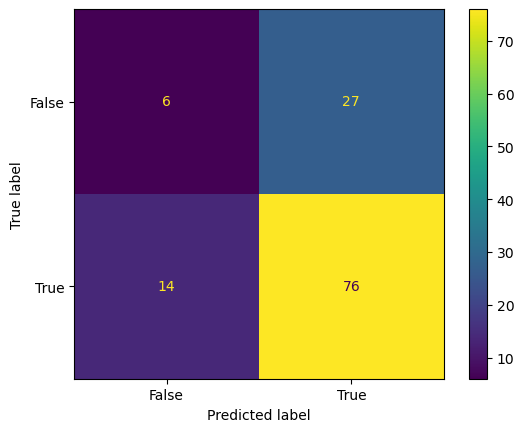

True negative: 6
False postive: 27
False negative: 14
True postive: 76


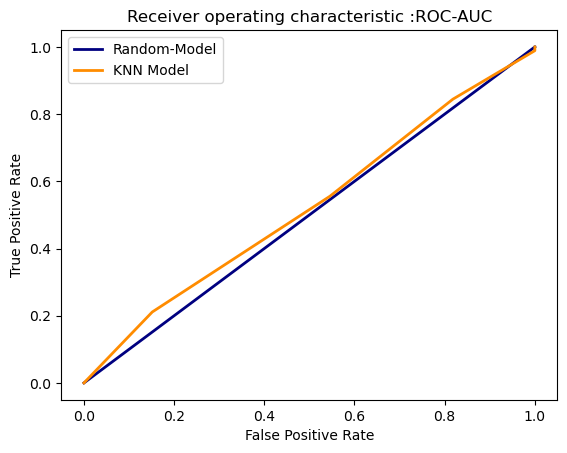

Computed Area Under the Curve (AUC) 0.5245791245791246


In [885]:
# ============================= Predictions ============================================================

y_pred_dt=knn_fit.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=knn_fit.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="KNN Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [887]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
knn_base = pd.DataFrame(data,
                  index = idx,
                  columns=['Base Model'])
knn_base

,Base Model
Accuracy,66.67
f1,0.79
Precision,0.74
Recall,0.84


**BY Hyper Tune**

accuray is: 69.11
F1 is: 0.81
Precision is: 0.73
Recall is: 0.91
              precision    recall  f1-score   support

           0       0.27      0.09      0.14        33
           1       0.73      0.91      0.81        90

    accuracy                           0.69       123
   macro avg       0.50      0.50      0.47       123
weighted avg       0.61      0.69      0.63       123



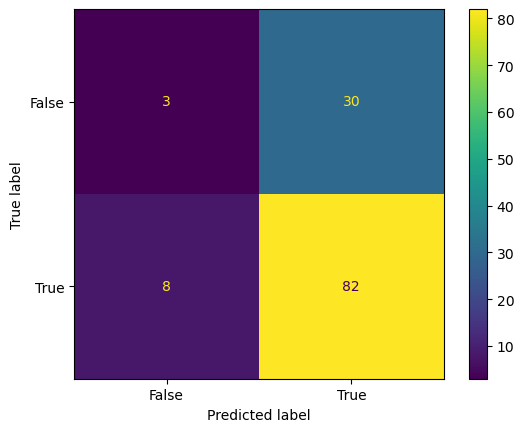

True negative: 3
False postive: 30
False negative: 8
True postive: 82


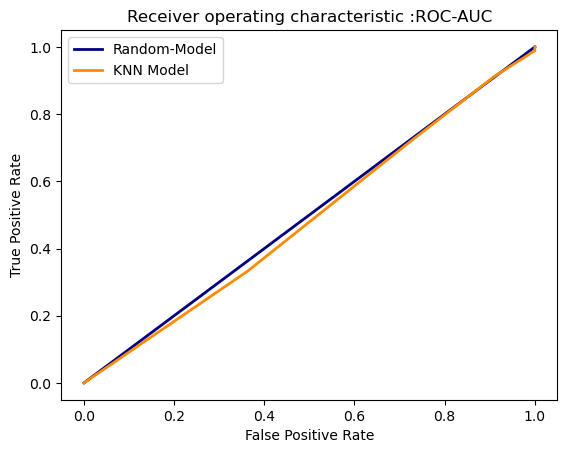

Computed Area Under the Curve (AUC) 0.48737373737373735


In [891]:
# ============================= Predictions ============================================================

y_pred_dt=grid_search.best_estimator_.predict(X_test)

# ============================ Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=grid_search.best_estimator_.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="KNN Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [893]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
knn_tune = pd.DataFrame(data,
                  index = idx,
                  columns=['Hyper Tune Model'])
knn_tune

,Hyper Tune Model
Accuracy,69.11
f1,0.81
Precision,0.73
Recall,0.91


In [895]:
compaire_df = pd.concat([knn_base,knn_tune],axis=1)
compaire_df

,Base Model,Hyper Tune Model
Accuracy,66.67,69.11
f1,0.79,0.81
Precision,0.74,0.73
Recall,0.84,0.91


## NB

In [898]:
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.naive_bayes import GaussianNB
GB=GaussianNB()   # Base model
GB

GaussianNB()

In [900]:
GB_fit = GB.fit(X_train,y_train)
GB_fit

GaussianNB()

In [902]:
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]  # 4 values
}

In [904]:
grid_search = GridSearchCV(GB,
                           param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=True)

grid_search 

GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06]},
             scoring='accuracy', verbose=True)

In [906]:
grid_search.fit(X_train,y_train) 

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06]},
             scoring='accuracy', verbose=True)

In [908]:
grid_search.best_estimator_ 

GaussianNB()

In [910]:
grid_search.best_score_

0.6639661925376211

In [912]:
grid_search.best_params_

{'var_smoothing': 1e-09}

**BY Base Model**

accuray is: 73.17
F1 is: 0.85
Precision is: 0.73
Recall is: 1.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
           1       0.73      1.00      0.85        90

    accuracy                           0.73       123
   macro avg       0.37      0.50      0.42       123
weighted avg       0.54      0.73      0.62       123



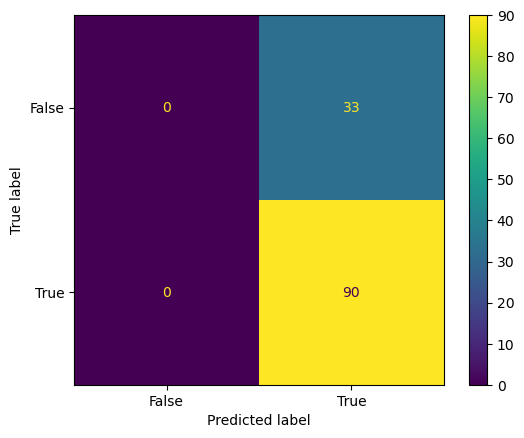

True negative: 0
False postive: 33
False negative: 0
True postive: 90


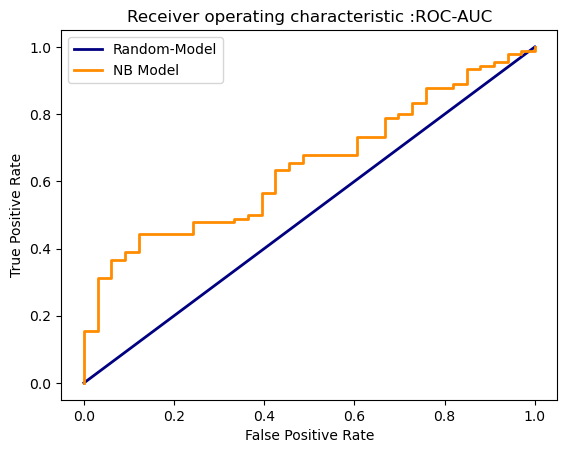

Computed Area Under the Curve (AUC) 0.6461279461279461


In [917]:
# =============================  Predictions ============================================================

y_pred_dt=GB_fit.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix  =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=GB_fit.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="NB Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [919]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
nb_base = pd.DataFrame(data,
                  index = idx,
                  columns=['Base Model'])
nb_base

,Base Model
Accuracy,73.17
f1,0.85
Precision,0.73
Recall,1.00


**BY Hyper Tune**

accuray is: 73.17
F1 is: 0.85
Precision is: 0.73
Recall is: 1.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
           1       0.73      1.00      0.85        90

    accuracy                           0.73       123
   macro avg       0.37      0.50      0.42       123
weighted avg       0.54      0.73      0.62       123



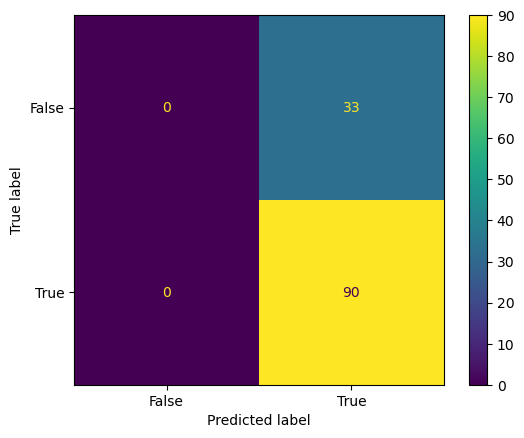

True negative: 0
False postive: 33
False negative: 0
True postive: 90


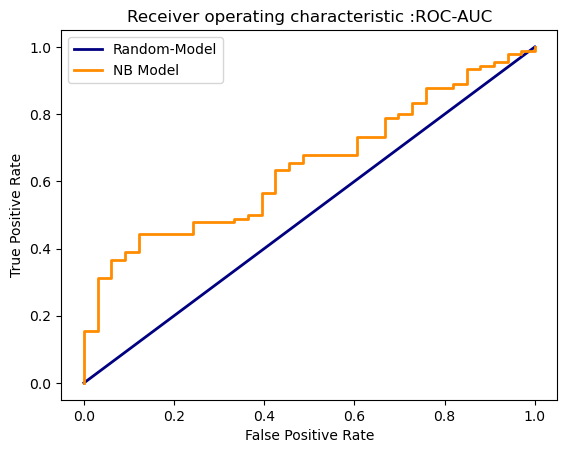

Computed Area Under the Curve (AUC) 0.6461279461279461


In [922]:
# ============================= Predictions ============================================================

y_pred_dt=grid_search.best_estimator_.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=grid_search.best_estimator_.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="NB Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [924]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
nb_tune = pd.DataFrame(data,
                  index = idx,
                  columns=['Hyper Tune Model'])
nb_tune

,Hyper Tune Model
Accuracy,73.17
f1,0.85
Precision,0.73
Recall,1.00


In [926]:
compaire_df = pd.concat([nb_base,nb_tune],axis=1)
compaire_df

,Base Model,Hyper Tune Model
Accuracy,73.17,73.17
f1,0.85,0.85
Precision,0.73,0.73
Recall,1.00,1.00


## Logistic Regression**

In [929]:
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression()   # Base model
LR

LogisticRegression()

In [931]:
LR_fit = LR.fit(X_train,y_train)
LR_fit

LogisticRegression()

In [933]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],        
    'penalty': ['l2'],             
    'solver': ['lbfgs']             
}

In [935]:
grid_search = GridSearchCV(LR,
                           param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=True)

grid_search

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='accuracy', verbose=True)

In [937]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='accuracy', verbose=True)

In [939]:
grid_search.best_estimator_ 

LogisticRegression(C=0.01)

In [941]:
grid_search.best_score_

0.6761698618841476

In [943]:
grid_search.best_params_

{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}

**BY Base Model**

accuray is: 73.17
F1 is: 0.85
Precision is: 0.73
Recall is: 1.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
           1       0.73      1.00      0.85        90

    accuracy                           0.73       123
   macro avg       0.37      0.50      0.42       123
weighted avg       0.54      0.73      0.62       123



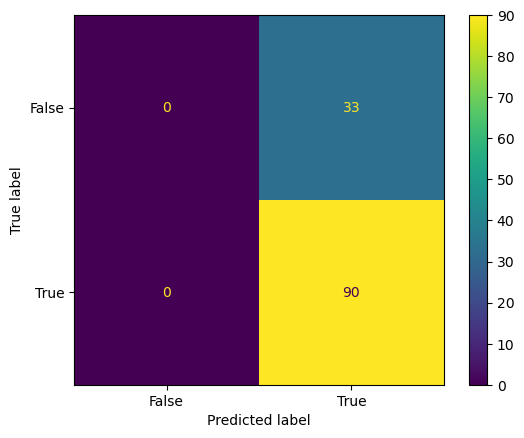

True negative: 0
False postive: 33
False negative: 0
True postive: 90


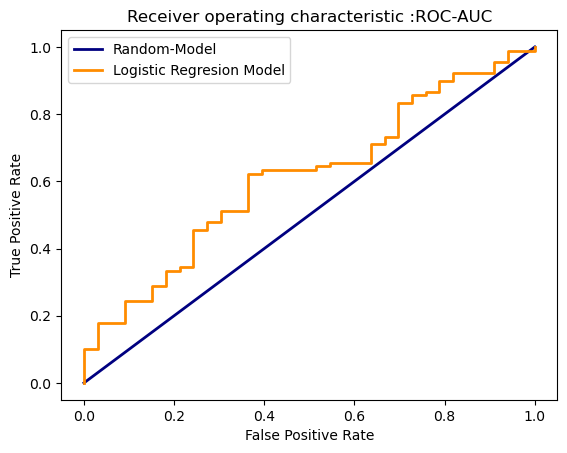

Computed Area Under the Curve (AUC) 0.6131313131313131


In [946]:
# ============================= Predictions ============================================================

y_pred_dt=LR_fit.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#===================================== ROC-AUC curve ================================================================

y_dt_pred_prob=LR_fit.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Logistic Regresion Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [948]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
log_base = pd.DataFrame(data,
                  index = idx,
                  columns=['Base Model'])
log_base

,Base Model
Accuracy,73.17
f1,0.85
Precision,0.73
Recall,1.00


**BY Hyper Tune**

accuray is: 73.17
F1 is: 0.85
Precision is: 0.73
Recall is: 1.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
           1       0.73      1.00      0.85        90

    accuracy                           0.73       123
   macro avg       0.37      0.50      0.42       123
weighted avg       0.54      0.73      0.62       123



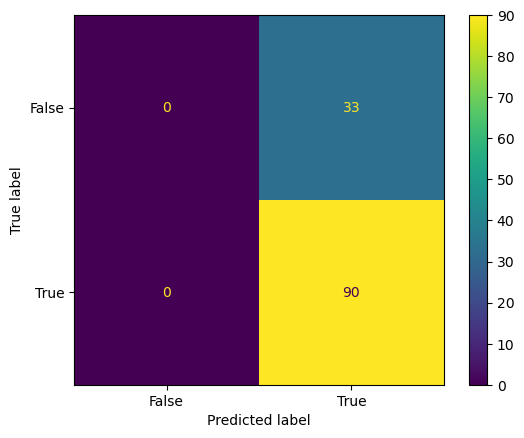

True negative: 0
False postive: 33
False negative: 0
True postive: 90


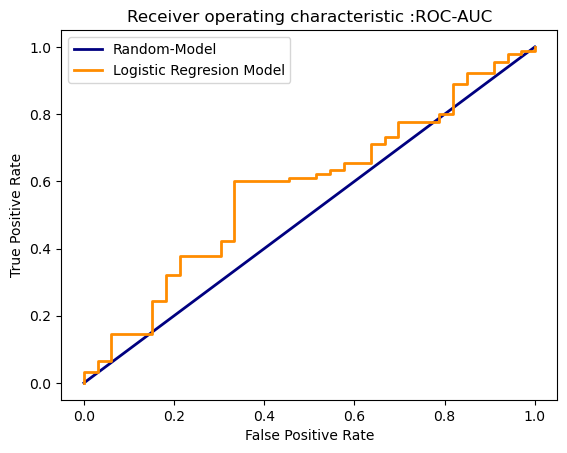

Computed Area Under the Curve (AUC) 0.5781144781144781


In [951]:
# =============================  Predictions ============================================================

y_pred_dt=grid_search.best_estimator_.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# =============================== Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=grid_search.best_estimator_.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Logistic Regresion Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [953]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
log_tune = pd.DataFrame(data,
                  index = idx,
                  columns=['Hyper Tune Model'])
log_tune

,Hyper Tune Model
Accuracy,73.17
f1,0.85
Precision,0.73
Recall,1.00


In [955]:
compaire_df = pd.concat([log_base,log_tune],axis=1)
compaire_df

,Base Model,Hyper Tune Model
Accuracy,73.17,73.17
f1,0.85,0.85
Precision,0.73,0.73
Recall,1.00,1.00


## Decision Tree

In [959]:
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.tree import DecisionTreeClassifier
grid_tree=DecisionTreeClassifier()   # Base model
grid_tree

DecisionTreeClassifier()

In [961]:
grid_tree_fit = grid_tree.fit(X_train,y_train)
grid_tree_fit

DecisionTreeClassifier()

In [963]:
param_grid = {
    "criterion":['gini','entropy'], 
    'max_depth': [3, 4, 5, 6, 7, 8], 
    'min_samples_split': [2, 3, 4],  
    'min_samples_leaf': [1, 2, 3, 4], 
    'random_state': [0, 42] 
}

In [965]:
grid_search = GridSearchCV(grid_tree,  # Base model
                           param_grid, # params 
                           scoring='accuracy', # metric
                           cv=5,
                           verbose=True)

grid_search

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 3, 4],
                         'random_state': [0, 42]},
             scoring='accuracy', verbose=True)

In [967]:
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 3, 4],
                         'random_state': [0, 42]},
             scoring='accuracy', verbose=True)

In [968]:
grid_search.best_estimator_ 

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=4,
                       random_state=0)

In [971]:
grid_search.best_score_

0.6761698618841476

In [973]:
grid_search.best_params_

{'criterion': 'entropy',
 'max_depth': 3,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'random_state': 0}

**BY Base Model**

accuray is: 59.35
F1 is: 0.72
Precision is: 0.73
Recall is: 0.71
              precision    recall  f1-score   support

           0       0.26      0.27      0.26        33
           1       0.73      0.71      0.72        90

    accuracy                           0.59       123
   macro avg       0.49      0.49      0.49       123
weighted avg       0.60      0.59      0.60       123



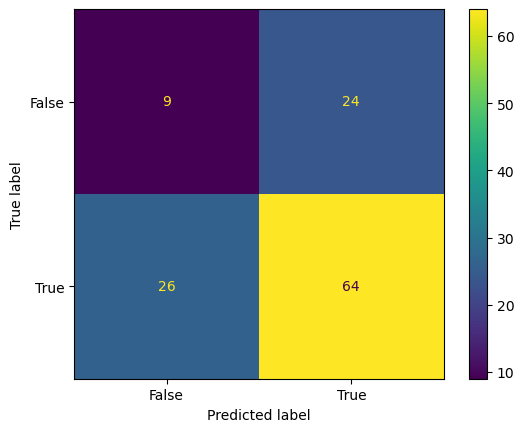

True negative: 9
False postive: 24
False negative: 26
True postive: 64


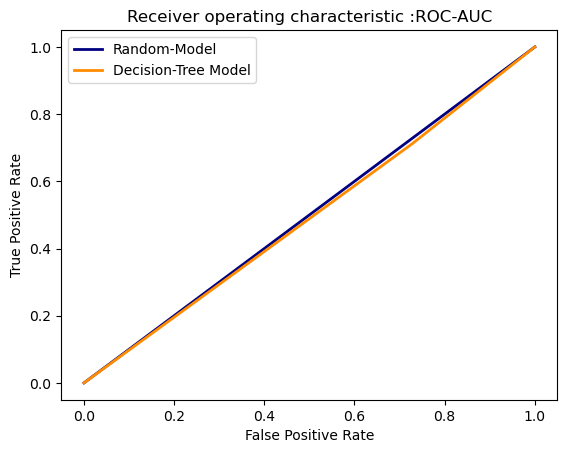

Computed Area Under the Curve (AUC) 0.4919191919191919


In [976]:
# ============================  Predictions ============================================================

y_pred_dt=grid_tree_fit.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=grid_tree_fit.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Decision-Tree Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [978]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
tree_base = pd.DataFrame(data,
                  index = idx,
                  columns=['Base Model'])
tree_base

,Base Model
Accuracy,59.35
f1,0.72
Precision,0.73
Recall,0.71


**BY Hyper tune**

accuray is: 70.73
F1 is: 0.82
Precision is: 0.74
Recall is: 0.93
              precision    recall  f1-score   support

           0       0.33      0.09      0.14        33
           1       0.74      0.93      0.82        90

    accuracy                           0.71       123
   macro avg       0.54      0.51      0.48       123
weighted avg       0.63      0.71      0.64       123



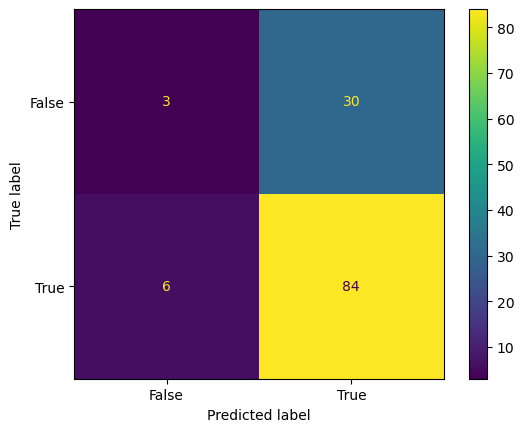

True negative: 3
False postive: 30
False negative: 6
True postive: 84


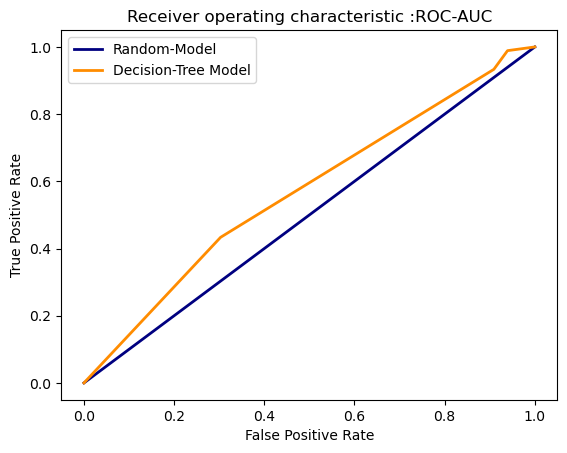

Computed Area Under the Curve (AUC) 0.5691919191919192


In [981]:
# ============================= Predictions ============================================================

y_pred_dt=grid_search.best_estimator_.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#=======================================  ROC-AUC curve ================================================================

y_dt_pred_prob=grid_search.best_estimator_.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Decision-Tree Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [983]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
tree_tune = pd.DataFrame(data,
                  index = idx,
                  columns=['Hyper Tune Model'])
tree_tune

,Hyper Tune Model
Accuracy,70.73
f1,0.82
Precision,0.74
Recall,0.93


In [985]:
compaired_df = pd.concat([tree_base,tree_tune],axis=1)
compaired_df

,Base Model,Hyper Tune Model
Accuracy,59.35,70.73
f1,0.72,0.82
Precision,0.73,0.74
Recall,0.71,0.93


## Random Forest

In [988]:
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.ensemble import RandomForestClassifier
RF=RandomForestClassifier()   # Base model
RF

RandomForestClassifier()

In [990]:
RF_fit = RF.fit(X_train,y_train)
RF_fit

RandomForestClassifier()

In [992]:
param_grid = {
    'n_estimators': [50, 100, 200],        
    'max_depth': [None, 5, 10, 20],         
    'min_samples_split': [2, 5, 10],      
    'min_samples_leaf': [1, 2, 4],         
    'bootstrap': [True, False]              
}

In [994]:
grid_search = GridSearchCV(RF,
                           param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=True)

grid_search

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=True)

In [996]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=True)

In [1000]:
grid_search.best_estimator_ 

RandomForestClassifier(max_depth=5, min_samples_leaf=4)

In [1002]:
grid_search.best_score_

0.6883735312306741

In [1003]:
grid_search.best_params_

{'bootstrap': True,
 'max_depth': 5,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'n_estimators': 100}

**BY Base Model**

accuray is: 65.04
F1 is: 0.78
Precision is: 0.72
Recall is: 0.87
              precision    recall  f1-score   support

           0       0.14      0.06      0.09        33
           1       0.72      0.87      0.78        90

    accuracy                           0.65       123
   macro avg       0.43      0.46      0.43       123
weighted avg       0.56      0.65      0.60       123



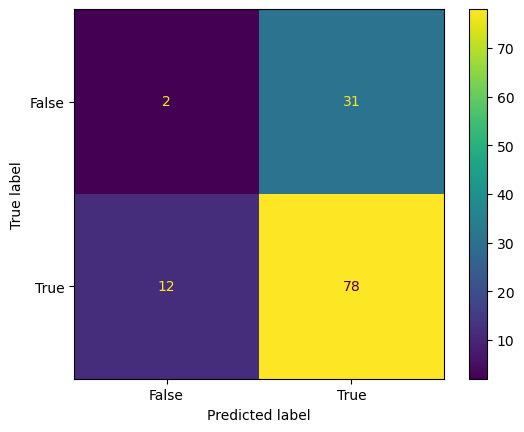

True negative: 2
False postive: 31
False negative: 12
True postive: 78


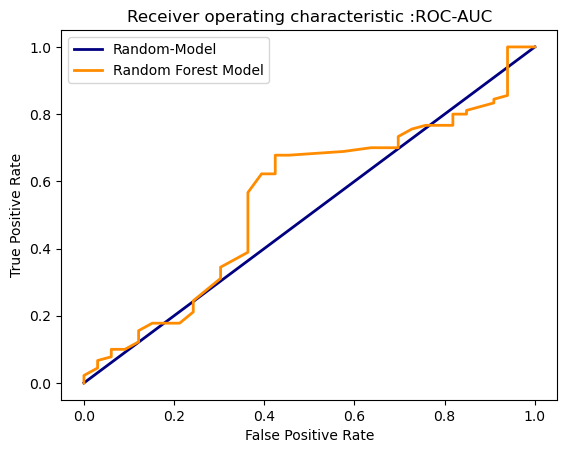

Computed Area Under the Curve (AUC) 0.5476430976430977


In [1005]:
# ============================= Predictions ============================================================

y_pred_dt=RF_fit.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ================================ Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#===================================== ROC-AUC curve ================================================================

y_dt_pred_prob=RF_fit.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Random Forest Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [1006]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
rf_base = pd.DataFrame(data,
                  index = idx,
                  columns=['Base Model'])
rf_base

,Base Model
Accuracy,65.04
f1,0.78
Precision,0.72
Recall,0.87


**BY Hyper Tune**

accuray is: 73.98
F1 is: 0.85
Precision is: 0.74
Recall is: 0.99
              precision    recall  f1-score   support

           0       0.67      0.06      0.11        33
           1       0.74      0.99      0.85        90

    accuracy                           0.74       123
   macro avg       0.70      0.52      0.48       123
weighted avg       0.72      0.74      0.65       123



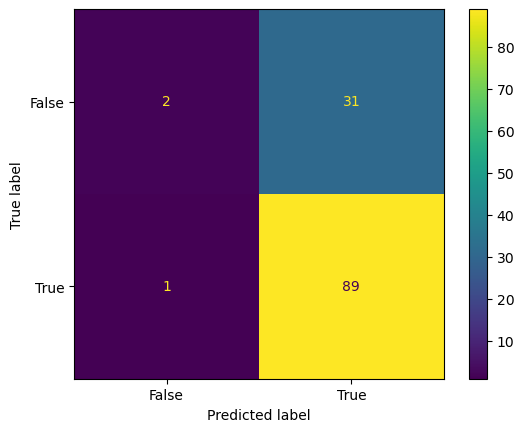

True negative: 2
False postive: 31
False negative: 1
True postive: 89


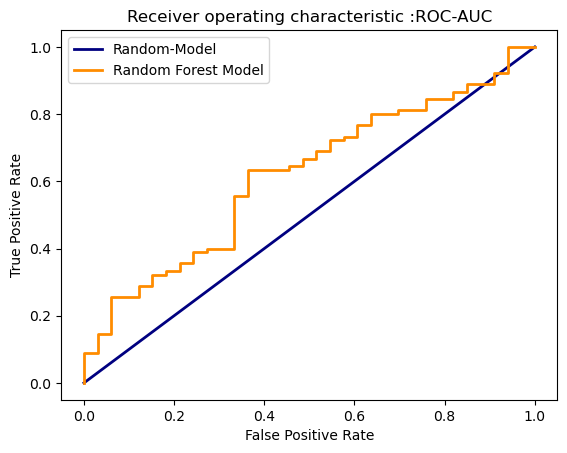

Computed Area Under the Curve (AUC) 0.6178451178451179


In [1008]:
# =============================  Predictions ============================================================

y_pred_dt=grid_search.best_estimator_.predict(X_test)

# ============================  Metrics ==================================================================

acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

print("accuray is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# =============================== Confusion matrix =========================================================================

cmt = confusion_matrix(y_test,y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cmt,
                            display_labels = [False, True])
disp.plot()
plt.grid(False)
plt.show()


tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False postive:",fp)
print("False negative:",fn)
print("True postive:",tp)

#======================================= ROC-AUC curve ================================================================

y_dt_pred_prob=grid_search.best_estimator_.predict_proba(X_test)[:,1]   # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob) 
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Random Forest Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()
print("Computed Area Under the Curve (AUC)",auc(fpr, tpr))

In [1018]:
acc_dt = round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt  =round(f1_score(y_test,y_pred_dt),2)
precision_dt =round(precision_score(y_test,y_pred_dt),2)
recall_dt    =round(recall_score(y_test,y_pred_dt),2)

data = [acc_dt,f1_dt,precision_dt,recall_dt]
idx = ['Accuracy','f1','Precision','Recall']
rf_tune = pd.DataFrame(data,
                  index = idx,
                  columns=['Hyper Tune Model'])
rf_tune

,Hyper Tune Model
Accuracy,73.98
f1,0.85
Precision,0.74
Recall,0.99


In [1010]:
compaire_df = pd.concat([rf_base,rf_tune],axis=1)
compaire_df

,Base Model,Hyper Tune Model
Accuracy,65.04,73.98
f1,0.78,0.85
Precision,0.72,0.74
Recall,0.87,0.99


In [1024]:
# best model Hyper paramter random forest data3
best_model = grid_search.best_estimator_ 

In [1026]:
import joblib
joblib.dump(best_model, "loan_model.pkl")


['loan_model.pkl']

In [1030]:
print(y_train.value_counts())

Loan_Status
1    332
0    159
Name: count, dtype: int64
